# Моделирование распространения фейков и фактчекинга через конкурентную перколяцию

Этот ноутбук реализует вычислительную часть исследования инфодемий. Сеть пользователей представляется как набор **эхо-камер**: внутри групп связи плотные, между группами есть редкие мосты, а отдельные узлы имеют повышенную центральность и интерпретируются как **инфлюенсеры**.

В модели одновременно распространяются две конкурирующие волны:

| Обозначение | Смысл |
|---|---|
| `S` | пользователь пока не видел фейк или фактчек |
| `F` | пользователь поверил в фейк и может распространить его дальше |
| `C` | пользователь получил фактчек и дальше распространяет корректирующую информацию |

Основные параметры модели:

| Параметр | Интерпретация |
|---|---|
| `p` | базовая вероятность передачи фейка по социальной связи |
| `w` | эмоциональное усиление фейка: чем выше `w`, тем заразнее фейк |
| `r` | сила фактчека: вероятность распространения или переубеждения |
| `delay` | задержка между запуском фейка и запуском фактчека |

Цель вычислительной части — показать, при каких условиях локальный вброс превращается в массовую инфодемию, и какие стратегии фактчека помогают опустить систему ниже перколяционного порога.

---

## Карта ноутбука

1. Подготовка библиотек и глобальных параметров.
2. Генерация сети эхо-камер.
3. Визуализация сети и состояний пользователей.
4. Выбор стартовых узлов фейка и фактчека.
5. Модель конкурентной перколяции.
6. Демонстрационный запуск.
7. Monte Carlo-сравнение стратегий фактчека.
8. Фазовые карты `p × r`.
9. Фазовые карты `w × r`.
10. Анализ роли мостов между эхо-камерами.
11. Доверительные интервалы и итоговые таблицы.
12. Устойчивость результатов на разных сетях.
13. Чувствительность к порогу инфодемии.
14. Проверка разных размеров сети.
15. Влияние задержки фактчека.
16. Оценка минимальной силы фактчека `r`, необходимой для подавления фейка.
17. Сохранение таблиц и графиков.

## 1. Подготовка окружения

In [ ]:
import os
import math
import random
import warnings
import itertools

from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42

rng = np.random.default_rng(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# Режим вычислений
# ============================================================
# FAST_MODE = True  -> быстрый черновой прогон.
# FAST_MODE = False -> финальные настройки для более гладких графиков.
FAST_MODE = False

if FAST_MODE:
    STRATEGY_RUNS = 60
    BRIDGE_RUNS = 80
    DELAY_RUNS = 60
    HEATMAP_RUNS_PER_CELL = 30
    WR_RUNS_PER_CELL = 30
    HEATMAP_GRID_SIZE = 10
    ROBUSTNESS_NETWORKS = 3
    ROBUSTNESS_RUNS_PER_NETWORK = 30
    SIZE_RUNS = 40
else:
    STRATEGY_RUNS = 300
    BRIDGE_RUNS = 300
    DELAY_RUNS = 300
    HEATMAP_RUNS_PER_CELL = 100
    WR_RUNS_PER_CELL = 100
    HEATMAP_GRID_SIZE = 16
    ROBUSTNESS_NETWORKS = 5
    ROBUSTNESS_RUNS_PER_NETWORK = 60
    SIZE_RUNS = 100

# Базовые параметры сети. Их удобно хранить отдельно, потому что они используются
# в нескольких экспериментах: базовая сеть, устойчивость, мосты, размеры сети.
BASE_NETWORK_KWARGS = {
    "n_communities": 3,
    "community_size": 180,
    "m_intra": 3,
    "triangle_prob": 0.25,
    "influencers_per_community": 2,
    "influencer_extra_edges": 55,
    "bridges_per_pair": 4,
    "bridge_weight": 0.75,
}

# Состояния узлов
S, F, C = 0, 1, 2

STATE_NAMES = {
    S: "Не знает",
    F: "Фейк",
    C: "Фактчек",
}

STATE_COLORS = {
    S: "#BDBDBD",  # серый
    F: "#E63946",  # красный
    C: "#2A9D8F",  # зеленый
}

STRATEGY_RU = {
    "none": "Без фактчека",
    "random": "Случайный узел",
    "same_community_random": "Случайный в исходной эхо-камере",
    "other_community_random": "Случайный в другой эхо-камере",
    "bridge": "Мостовой узел",
    "high_degree": "Самый связный узел",
    "influencer": "Инфлюенсер",
}

COMMUNITY_CMAP = plt.get_cmap("tab10")

# Более аккуратный стиль графиков для финального текста работы.
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


def ci95_from_std(std, n):
    """95% доверительный интервал для среднего через стандартное отклонение."""
    if n <= 1 or pd.isna(std):
        return 0.0
    return 1.96 * std / np.sqrt(n)


def ci95_for_probability(probability, n):
    """Биномиальный 95% доверительный интервал для доли/вероятности."""
    if n <= 0 or pd.isna(probability):
        return 0.0
    return 1.96 * np.sqrt(probability * (1 - probability) / n)


Эта ячейка подготавливает рабочую среду: подключает библиотеки для графов (`networkx`), численных расчетов (`numpy`, `pandas`) и визуализации (`matplotlib`).

Здесь же задаются глобальные настройки экспериментов:

- `STRATEGY_RUNS` — число повторов для сравнения стратегий фактчека;
- `BRIDGE_RUNS` — число повторов для эксперимента с мостами;
- `DELAY_RUNS` — число повторов для эксперимента с задержкой;
- `HEATMAP_RUNS_PER_CELL` — число повторов в каждой точке фазовой карты `p × r`;
- `WR_RUNS_PER_CELL` — число повторов в каждой точке фазовой карты `w × r`;
- `HEATMAP_GRID_SIZE` — размерность тепловой карты;
- `ROBUSTNESS_NETWORKS` — число разных случайных сетей для проверки устойчивости;
- `FAST_MODE` — переключатель между быстрым черновым прогоном и финальными настройками.


## 2. Генерация сети эхо-камер

In [ ]:
@dataclass
class NetworkBundle:
    G: nx.Graph
    communities: dict
    influencers: list
    bridge_nodes: list
    community_nodes: dict


def _ensure_connected_within(G, nodes, rng):
    """
    Соединяет компоненты внутри одной эхо-камеры,
    если генератор случайно сделал ее разорванной.
    """
    sub = G.subgraph(nodes)
    components = [list(c) for c in nx.connected_components(sub)]

    if len(components) <= 1:
        return

    for left, right in zip(components[:-1], components[1:]):
        u = int(rng.choice(left))
        v = int(rng.choice(right))
        G.add_edge(u, v, edge_type="intra", weight=1.0)


def generate_echo_chamber_network(
    n_communities=3,
    community_size=180,
    m_intra=3,
    triangle_prob=0.25,
    influencers_per_community=2,
    influencer_extra_edges=55,
    bridges_per_pair=4,
    bridge_weight=0.75,
    seed=42,
):
    """
    Генерирует граф из нескольких эхо-камер.

    Что моделируем:
    - внутри каждой группы связи плотнее;
    - структура неравномерная: есть обычные пользователи и хабы;
    - инфлюенсеры получают дополнительные связи;
    - между группами есть редкие мосты.
    """
    rng = np.random.default_rng(seed)
    G = nx.Graph()

    communities = {}
    community_nodes = {}
    all_influencers = []

    offset = 0

    for c in range(n_communities):
        # Powerlaw-cluster graph дает неравномерные степени + локальную кластеризацию.
        H = nx.powerlaw_cluster_graph(
            n=community_size,
            m=m_intra,
            p=triangle_prob,
            seed=int(rng.integers(1, 1_000_000_000)),
        )

        H = nx.convert_node_labels_to_integers(H, first_label=offset)
        G = nx.compose(G, H)

        nodes = list(range(offset, offset + community_size))
        community_nodes[c] = nodes

        for node in nodes:
            G.nodes[node]["community"] = c
            G.nodes[node]["influencer"] = False
            G.nodes[node]["is_bridge"] = False
            communities[node] = c

        _ensure_connected_within(G, nodes, rng)

        for u, v in G.subgraph(nodes).edges():
            G[u][v]["edge_type"] = "intra"
            G[u][v]["weight"] = 1.0

        offset += community_size

    # Назначаем инфлюенсеров: берем самые связные узлы внутри каждой эхо-камеры.
    for c, nodes in community_nodes.items():
        ranked = sorted(
            [(node, G.degree(node)) for node in nodes],
            key=lambda x: x[1],
            reverse=True,
        )

        influencers = [node for node, _ in ranked[:influencers_per_community]]

        for inf in influencers:
            G.nodes[inf]["influencer"] = True
            all_influencers.append(inf)

            # Усиливаем инфлюенсера дополнительными связями внутри его группы.
            candidates = [
                node for node in nodes
                if node != inf and not G.has_edge(inf, node)
            ]

            if candidates and influencer_extra_edges > 0:
                k = min(influencer_extra_edges, len(candidates))
                targets = rng.choice(candidates, size=k, replace=False)

                for target in targets:
                    target = int(target)
                    G.add_edge(inf, target, edge_type="intra", weight=1.0)

    # Добавляем редкие межгрупповые мосты.
    bridge_nodes = set()

    for c1, c2 in itertools.combinations(range(n_communities), 2):
        added = 0
        attempts = 0
        max_attempts = max(100, bridges_per_pair * 100)

        while added < bridges_per_pair and attempts < max_attempts:
            attempts += 1

            u = int(rng.choice(community_nodes[c1]))
            v = int(rng.choice(community_nodes[c2]))

            if not G.has_edge(u, v):
                G.add_edge(u, v, edge_type="bridge", weight=bridge_weight)

                G.nodes[u]["is_bridge"] = True
                G.nodes[v]["is_bridge"] = True

                bridge_nodes.update([u, v])
                added += 1

    # Подстраховка: у каждого ребра должен быть тип и вес.
    for _, _, data in G.edges(data=True):
        data.setdefault("edge_type", "intra")
        data.setdefault("weight", 1.0)

    return NetworkBundle(
        G=G,
        communities=communities,
        influencers=all_influencers,
        bridge_nodes=sorted(bridge_nodes),
        community_nodes=community_nodes,
    )

Здесь задается генератор социальной сети. Сеть строится не как случайный однородный граф, а как набор эхо-камер:

- `n_communities` — число эхо-камер;
- `community_size` — размер каждой группы;
- `m_intra` и `triangle_prob` — параметры плотности и кластеризации внутри эхо-камеры;
- `influencers_per_community` — число инфлюенсеров в каждой группе;
- `influencer_extra_edges` — сколько дополнительных связей получает инфлюенсер;
- `bridges_per_pair` — число мостов между каждой парой эхо-камер;
- `bridge_weight` — вес межгрупповой связи.

Смысл генератора: внутри сообщества пользователи связаны плотнее, а между сообществами есть только редкие переходы. Инфлюенсеры получают дополнительные связи и становятся потенциально более опасными точками запуска фейка.

**Вывод для текста работы:** модель учитывает неоднородность реальных социальных сетей: пользователи объединяются в поляризованные группы, а узлы с высокой степенью играют роль лидеров мнений. Это позволяет изучать не только силу фейка, но и структурные условия его распространения.

## 3. Визуализация графа и состояний

In [ ]:
def community_layout(G, seed=42, radius=4.0, community_scale=1.15):
    """
    Раскладка графа:
    - каждая эхо-камера лежит отдельным облаком;
    - внутри камеры используется spring_layout.
    """
    rng = np.random.default_rng(seed)

    communities = sorted(set(nx.get_node_attributes(G, "community").values()))
    k = len(communities)

    centers = {}
    for i, c in enumerate(communities):
        angle = 2 * math.pi * i / k
        centers[c] = radius * np.array([math.cos(angle), math.sin(angle)])

    pos = {}

    for c in communities:
        nodes = [
            n for n, d in G.nodes(data=True)
            if d["community"] == c
        ]

        sub = G.subgraph(nodes)

        local = nx.spring_layout(
            sub,
            seed=int(rng.integers(1, 1_000_000_000)),
            iterations=60,
        )

        points = np.array([local[n] for n in nodes])
        points = points - points.mean(axis=0)

        max_norm = np.max(np.linalg.norm(points, axis=1))

        if max_norm > 0:
            points = points / max_norm * community_scale

        for node, point in zip(nodes, points):
            pos[node] = centers[c] + point

    return pos


def _node_sizes(G, base_size=18):
    sizes = []

    for n in G.nodes():
        size = base_size

        if G.nodes[n].get("is_bridge", False):
            size += 35

        if G.nodes[n].get("influencer", False):
            size += 95

        sizes.append(size)

    return sizes


def plot_network_structure(
    G,
    pos=None,
    title="Структура сети: эхо-камеры, инфлюенсеры и мосты",
):
    if pos is None:
        pos = community_layout(G)

    fig, ax = plt.subplots(figsize=(10, 7))

    intra_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("edge_type") == "intra"
    ]

    bridge_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("edge_type") == "bridge"
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=intra_edges,
        width=0.4,
        alpha=0.14,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=bridge_edges,
        width=1.8,
        alpha=0.75,
        ax=ax,
    )

    communities = sorted(set(nx.get_node_attributes(G, "community").values()))

    for c in communities:
        nodes = [
            n for n, d in G.nodes(data=True)
            if d["community"] == c
        ]

        node_colors = [COMMUNITY_CMAP(c % 10)] * len(nodes)

        node_sizes = [
            120 if G.nodes[n].get("influencer", False)
            else 55 if G.nodes[n].get("is_bridge", False)
            else 22
            for n in nodes
        ]

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes,
            node_color=node_colors,
            node_size=node_sizes,
            linewidths=0.35,
            edgecolors="black",
            alpha=0.9,
            ax=ax,
        )

    legend_items = [
        Line2D([0], [0], marker="o", linestyle="", markersize=6, label="Обычный пользователь"),
        Line2D([0], [0], marker="o", linestyle="", markersize=9, label="Мостовой узел"),
        Line2D([0], [0], marker="o", linestyle="", markersize=12, label="Инфлюенсер"),
        Line2D([0], [0], linestyle="-", linewidth=2, label="Межгрупповой мост"),
    ]

    ax.legend(handles=legend_items, loc="upper right", frameon=True)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return fig, ax, pos


def plot_network_state(G, states, pos, title="Состояние сети"):
    fig, ax = plt.subplots(figsize=(10, 7))

    intra_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("edge_type") == "intra"
    ]

    bridge_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("edge_type") == "bridge"
    ]

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=intra_edges,
        width=0.35,
        alpha=0.10,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=bridge_edges,
        width=1.5,
        alpha=0.45,
        ax=ax,
    )

    node_colors = [STATE_COLORS[int(states[n])] for n in G.nodes()]
    node_sizes = _node_sizes(G, base_size=18)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        linewidths=0.25,
        edgecolors="black",
        alpha=0.92,
        ax=ax,
    )

    legend_items = [
        Line2D([0], [0], marker="o", linestyle="", markersize=8, color=STATE_COLORS[S], label="Не знает"),
        Line2D([0], [0], marker="o", linestyle="", markersize=8, color=STATE_COLORS[F], label="Верит в фейк"),
        Line2D([0], [0], marker="o", linestyle="", markersize=8, color=STATE_COLORS[C], label="Получил фактчек"),
    ]

    ax.legend(handles=legend_items, loc="upper right", frameon=True)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return fig, ax



Ячейка содержит функции визуализации:

- `community_layout` раскладывает граф так, чтобы эхо-камеры были видны как отдельные облака;
- `plot_network_structure` показывает структуру сети: группы, инфлюенсеров и межгрупповые мосты;
- `plot_network_state` показывает текущее состояние пользователей: кто не знает, кто верит в фейк, кто получил фактчек.

Визуализация нужна не только для красоты. Она помогает проверить, что сгенерированная сеть соответствует теоретической постановке: группы отделены друг от друга, внутри них есть хабы, а между группами есть ограниченное число мостов.

**Вывод для текста работы:** графовая визуализация подтверждает, что синтетическая сеть имеет структуру эхо-камер: плотные внутренние связи и редкие межгрупповые каналы, через которые может происходить перколяция фейка.

## 4. Стратегии выбора стартовых узлов

In [ ]:
def choose_fake_seed(G, fake_community=0, rng=None):
    """
    Старт фейка: инфлюенсер внутри выбранной эхо-камеры.
    """
    if rng is None:
        rng = np.random.default_rng()

    influencers = [
        n for n, d in G.nodes(data=True)
        if d.get("community") == fake_community and d.get("influencer", False)
    ]

    if influencers:
        return int(rng.choice(influencers))

    candidates = [
        n for n, d in G.nodes(data=True)
        if d.get("community") == fake_community
    ]

    return int(max(candidates, key=lambda n: G.degree(n)))


def choose_factcheck_seed(G, strategy, fake_seed, fake_community=0, rng=None):
    """
    Выбор стартовой точки фактчека.

    strategy:
    - "none": фактчек не запускается;
    - "random": случайный узел;
    - "same_community_random": случайный узел в той же эхо-камере;
    - "other_community_random": случайный узел в другой эхо-камере;
    - "bridge": мостовой узел;
    - "high_degree": самый связный узел;
    - "influencer": инфлюенсер в эхо-камере фейка.
    """
    if rng is None:
        rng = np.random.default_rng()

    if strategy == "none" or strategy is None:
        return None

    nodes = [n for n in G.nodes() if n != fake_seed]

    if strategy == "random":
        return int(rng.choice(nodes))

    if strategy == "same_community_random":
        candidates = [
            n for n in nodes
            if G.nodes[n].get("community") == fake_community
        ]

        return int(rng.choice(candidates)) if candidates else int(rng.choice(nodes))

    if strategy == "other_community_random":
        candidates = [
            n for n in nodes
            if G.nodes[n].get("community") != fake_community
        ]

        return int(rng.choice(candidates)) if candidates else int(rng.choice(nodes))

    if strategy == "bridge":
        candidates = [
            n for n in nodes
            if G.nodes[n].get("is_bridge", False)
        ]

        if not candidates:
            candidates = nodes

        return int(max(candidates, key=lambda n: G.degree(n)))

    if strategy == "high_degree":
        return int(max(nodes, key=lambda n: G.degree(n)))

    if strategy == "influencer":
        candidates = [
            n for n in nodes
            if G.nodes[n].get("community") == fake_community
            and G.nodes[n].get("influencer", False)
        ]

        if not candidates:
            candidates = [
                n for n in nodes
                if G.nodes[n].get("influencer", False)
            ]

        if not candidates:
            candidates = nodes

        return int(max(candidates, key=lambda n: G.degree(n)))

    raise ValueError(f"Неизвестная стратегия фактчека: {strategy}")

Фейк запускается через `choose_fake_seed`: по умолчанию он стартует у инфлюенсера в выбранной эхо-камере. Это моделирует ситуацию, когда дезинформация попадает к блогеру, лидеру мнений или крупному каналу.

Фактчек запускается через `choose_factcheck_seed`. Доступные стратегии:

| Стратегия | Смысл |
|---|---|
| `none` | фактчек не запускается |
| `random` | случайный пользователь |
| `same_community_random` | случайный пользователь в исходной эхо-камере |
| `other_community_random` | случайный пользователь в другой эхо-камере |
| `bridge` | мостовой узел между эхо-камерами |
| `high_degree` | самый связный узел во всей сети |
| `influencer` | инфлюенсер в исходной эхо-камере |

**Вывод для текста работы:** эта часть позволяет проверить центральную гипотезу: эффективность фактчека зависит не только от его силы, но и от того, в какой структурной точке сети он появляется.

## 5. Конкурентная перколяция фейка и фактчека

In [ ]:
def run_simulation(
    G,
    fake_seed,
    check_seed=None,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    outbreak_threshold=0.25,
    snapshot_steps=(0, 2, 4, 6, 10, 15, 30),
    check_spread_factor=1.0,
    check_conversion_factor=1.0,
    seed=42,
):
    """
    Конкурентная перколяция / independent cascade.

    Состояния:
    S = 0: не знает;
    F = 1: поверил в фейк;
    C = 2: получил фактчек.

    p: базовая вероятность передачи фейка;
    w: эмоциональное усиление фейка;
    r: вероятность распространения / переубеждения фактчеком;
    delay: задержка запуска фактчека.

    Важный момент:
    каждый активированный узел пытается передать информацию соседям один раз.
    Это ближе к перколяционной модели, чем к бесконечному заражению.
    """
    rng = np.random.default_rng(seed)

    n = G.number_of_nodes()

    states = np.zeros(n, dtype=np.int8)
    ever_fake = np.zeros(n, dtype=bool)

    active_fake = set()
    active_check = set()

    if fake_seed is not None:
        fake_seed = int(fake_seed)
        states[fake_seed] = F
        ever_fake[fake_seed] = True
        active_fake.add(fake_seed)

    # Одновременный запуск фактчека.
    if check_seed is not None and delay == 0:
        check_seed = int(check_seed)
        states[check_seed] = C
        active_check.add(check_seed)
        active_fake.discard(check_seed)

    history_rows = []
    snapshots = {}

    def record(t):
        fake_count = int(np.sum(states == F))
        checked_count = int(np.sum(states == C))
        susceptible_count = int(np.sum(states == S))
        ever_fake_count = int(np.sum(ever_fake))

        history_rows.append(
            {
                "t": t,
                "susceptible": susceptible_count,
                "fake": fake_count,
                "checked": checked_count,
                "ever_fake": ever_fake_count,
                "susceptible_share": susceptible_count / n,
                "fake_share": fake_count / n,
                "checked_share": checked_count / n,
                "ever_fake_share": ever_fake_count / n,
            }
        )

        if snapshot_steps is not None and t in snapshot_steps:
            snapshots[t] = states.copy()

    record(0)

    for t in range(1, steps + 1):

        # Запуск фактчека с задержкой.
        if check_seed is not None and t == delay:
            check_seed = int(check_seed)
            states[check_seed] = C
            active_check.add(check_seed)
            active_fake.discard(check_seed)

        fake_pressure = defaultdict(float)
        check_pressure = defaultdict(float)

        # Фейк пытается пройти по ребрам.
        for u in list(active_fake):
            if states[u] != F:
                continue

            for v in G.neighbors(u):
                if states[v] == C:
                    continue

                edge_weight = G[u][v].get("weight", 1.0)
                prob = min(1.0, p * w * edge_weight)

                if rng.random() < prob:
                    fake_pressure[int(v)] += prob

        # Фактчек пытается пройти по ребрам и переубедить F-узлы.
        for u in list(active_check):
            if states[u] != C:
                continue

            for v in G.neighbors(u):
                if states[v] == C:
                    continue

                edge_weight = G[u][v].get("weight", 1.0)

                if states[v] == F:
                    factor = check_conversion_factor
                else:
                    factor = check_spread_factor

                prob = min(1.0, r * factor * edge_weight)

                if rng.random() < prob:
                    check_pressure[int(v)] += prob

        new_fake = set()
        new_check = set()

        targets = set(fake_pressure.keys()) | set(check_pressure.keys())

        for v in targets:
            if states[v] == C:
                continue

            f_press = fake_pressure.get(v, 0.0)
            c_press = check_pressure.get(v, 0.0)

            # Уже поверившего в фейк может изменить только фактчек.
            if states[v] == F:
                if c_press > 0:
                    states[v] = C
                    new_check.add(v)
                continue

            # Узел S получил обе волны на одном шаге: решаем конфликт давлением.
            if f_press > 0 and c_press > 0:
                check_win_prob = c_press / (f_press + c_press)

                if rng.random() < check_win_prob:
                    states[v] = C
                    new_check.add(v)
                else:
                    states[v] = F
                    ever_fake[v] = True
                    new_fake.add(v)

            elif f_press > 0:
                states[v] = F
                ever_fake[v] = True
                new_fake.add(v)

            elif c_press > 0:
                states[v] = C
                new_check.add(v)

        active_fake = new_fake
        active_check = new_check

        record(t)

    history = pd.DataFrame(history_rows)
    peak_idx = int(history["fake_share"].idxmax())

    metrics = {
        "final_fake_share": float(history["fake_share"].iloc[-1]),
        "ever_fake_share": float(history["ever_fake_share"].iloc[-1]),
        "final_checked_share": float(history["checked_share"].iloc[-1]),
        "peak_fake_share": float(history["fake_share"].max()),
        "time_to_peak": int(history.loc[peak_idx, "t"]),
        "outbreak": int(history["ever_fake_share"].iloc[-1] >= outbreak_threshold),
        "fake_seed": fake_seed,
        "check_seed": check_seed,
        "p": p,
        "w": w,
        "r": r,
        "delay": delay,
    }

    return {
        "history": history,
        "states": states,
        "ever_fake": ever_fake,
        "snapshots": snapshots,
        "metrics": metrics,
    }

Это главная ячейка модели. Функция `run_simulation` реализует конкурентную перколяцию фейка и фактчека.

На каждом шаге времени:

1. активные `F`-узлы пытаются передать фейк соседям;
2. активные `C`-узлы пытаются передать фактчек соседям;
3. если пользователь получил обе волны одновременно, результат выбирается вероятностно по силе давления;
4. если пользователь уже верит в фейк, фактчек может перевести его в состояние `C`.

Вероятность передачи фейка задается как:

$$
\beta_F = \min(1, p \cdot w \cdot a_{uv}),
$$

где `p` — базовая заразность фейка, `w` — эмоциональное усиление, `a_uv` — вес ребра.

Вероятность действия фактчека задается как:

$$
\beta_C = \min(1, r \cdot a_{uv}).
$$

Функция возвращает:

- `history` — динамику долей `S`, `F`, `C` по шагам;
- `states` — финальные состояния узлов;
- `ever_fake` — кто хотя бы раз поверил в фейк;
- `snapshots` — снимки сети в заданные моменты;
- `metrics` — итоговые метрики симуляции.

**Вывод для текста работы:** модель интерпретирует распространение фейка как процесс образования кластера на графе, а фактчек — как конкурирующую волну, которая может блокировать или переубеждать зараженные узлы.

## 6. Графики динамики распространения

In [ ]:
def plot_dynamics(history, title="Динамика распространения фейка и фактчека"):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        history["t"],
        history["susceptible_share"],
        label="Не знают S(t)",
        linewidth=2,
    )

    ax.plot(
        history["t"],
        history["fake_share"],
        label="Верят в фейк F(t)",
        linewidth=2,
    )

    ax.plot(
        history["t"],
        history["checked_share"],
        label="Получили фактчек C(t)",
        linewidth=2,
    )

    ax.plot(
        history["t"],
        history["ever_fake_share"],
        label="Хотя бы раз поверили в фейк",
        linewidth=2,
        linestyle="--",
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Шаг времени")
    ax.set_ylabel("Доля пользователей")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax


def plot_state_snapshots(G, snapshots, pos, title="Снапшоты распространения"):
    if not snapshots:
        print("Нет снапшотов для отрисовки.")
        return None, None

    times = sorted(snapshots.keys())

    n = len(times)
    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
    axes = np.array(axes).reshape(-1)

    intra_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("edge_type") == "intra"
    ]

    bridge_edges = [
        (u, v) for u, v, d in G.edges(data=True)
        if d.get("edge_type") == "bridge"
    ]

    for ax, t in zip(axes, times):
        states = snapshots[t]

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=intra_edges,
            width=0.25,
            alpha=0.07,
            ax=ax,
        )

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=bridge_edges,
            width=1.1,
            alpha=0.35,
            ax=ax,
        )

        node_colors = [STATE_COLORS[int(states[node])] for node in G.nodes()]
        node_sizes = _node_sizes(G, base_size=10)

        nx.draw_networkx_nodes(
            G,
            pos,
            node_color=node_colors,
            node_size=node_sizes,
            linewidths=0.15,
            edgecolors="black",
            alpha=0.95,
            ax=ax,
        )

        ax.set_title(f"t = {t}")
        ax.axis("off")

    for ax in axes[len(times):]:
        ax.axis("off")

    legend_items = [
        Line2D([0], [0], marker="o", linestyle="", markersize=8, color=STATE_COLORS[S], label="Не знает"),
        Line2D([0], [0], marker="o", linestyle="", markersize=8, color=STATE_COLORS[F], label="Фейк"),
        Line2D([0], [0], marker="o", linestyle="", markersize=8, color=STATE_COLORS[C], label="Фактчек"),
    ]

    fig.legend(handles=legend_items, loc="upper center", ncol=3, frameon=True)
    fig.suptitle(title, fontsize=15, y=1.02)

    plt.tight_layout()
    plt.show()

    return fig, axes

Здесь собраны функции для анализа одного запуска:

- `plot_dynamics` строит кривые `S(t)`, `F(t)`, `C(t)` и накопительную долю `ever_fake`;
- `plot_state_snapshots` показывает состояние графа в несколько моментов времени;
- `plot_network_state` показывает финальное состояние сети.

Важно различать две метрики:

| Метрика | Что показывает |
|---|---|
| `fake_share` | кто верит в фейк прямо сейчас |
| `ever_fake_share` | кто хотя бы раз поверил в фейк |

`ever_fake_share` не падает, даже если пользователь позже получил фактчек. Поэтому для анализа ущерба полезна `ever_fake_share`, а для анализа успешности подавления — `final_fake_share`.

**Вывод для текста работы:** динамические графики позволяют разделить краткосрочный пик фейка и финальный остаток фейка после работы фактчека.

## 7. Создание базовой сети

Узлов: 540
Ребер: 1931
Инфлюенсеров: 6
Мостовых узлов: 24
Плотность графа: 0.0133


,community,nodes
0,0,180
1,1,180
2,2,180


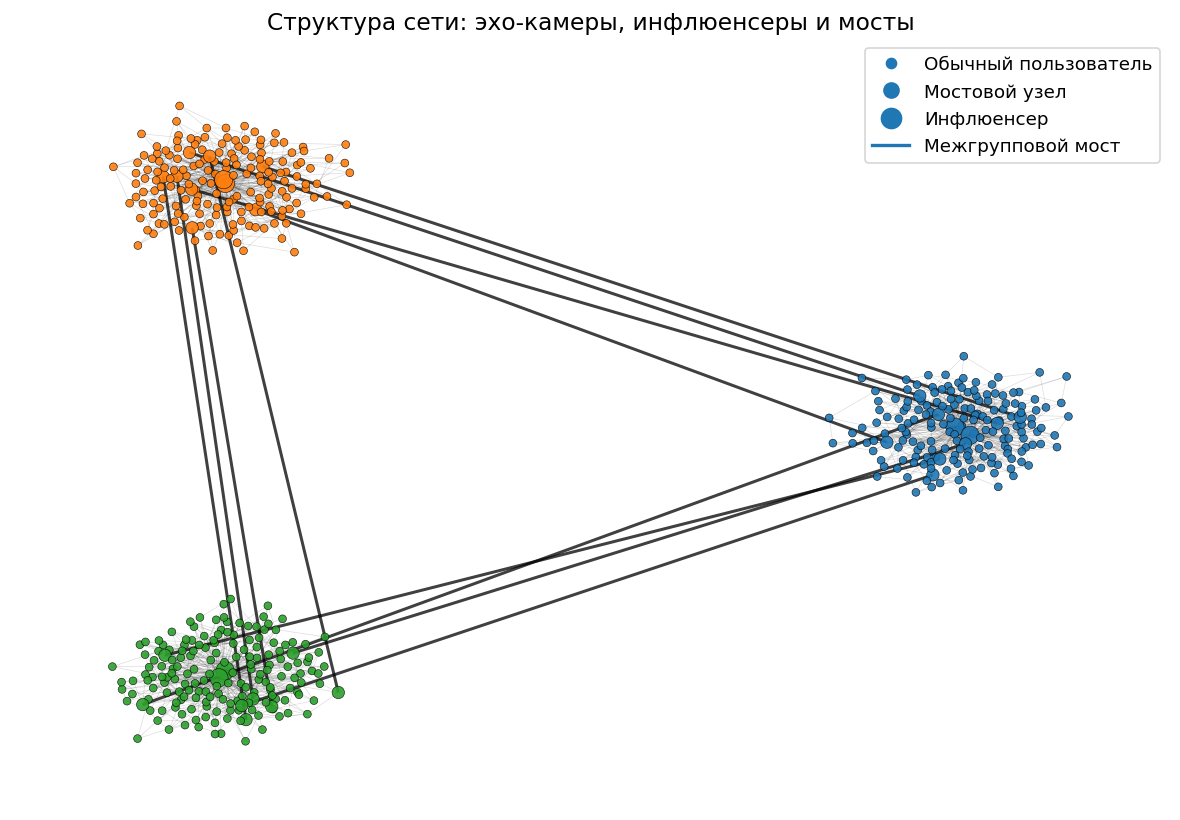

In [ ]:
bundle = generate_echo_chamber_network(
    **BASE_NETWORK_KWARGS,
    seed=SEED,
)

G = bundle.G
pos = community_layout(G, seed=SEED)

print(f"Узлов: {G.number_of_nodes()}")
print(f"Ребер: {G.number_of_edges()}")
print(f"Инфлюенсеров: {len(bundle.influencers)}")
print(f"Мостовых узлов: {len(bundle.bridge_nodes)}")
print(f"Плотность графа: {nx.density(G):.4f}")

community_counts = (
    pd.Series(nx.get_node_attributes(G, "community"))
    .value_counts()
    .sort_index()
    .rename_axis("community")
    .reset_index(name="nodes")
)

display(community_counts)

fig_network, ax_network, pos = plot_network_structure(G, pos)


Параметры текущего графа:

| Показатель | Значение в текущем прогоне |
|---|---:|
| Число узлов | 540 |
| Число ребер | 1931 |
| Число эхо-камер | 3 |
| Размер каждой эхо-камеры | 180 |
| Число инфлюенсеров | 6 |
| Число мостовых узлов | 24 |
| Плотность графа | 0.0133 |

Визуализация должна показывать три отдельные группы, внутри которых много связей, и несколько межгрупповых мостов.

**Вывод для текста работы:** построенная сеть является разреженной, но структурированной. Это соответствует идее социальных платформ: пользователи не связаны со всеми подряд, а образуют локальные сообщества с редкими каналами перехода между ними.

## 8. Демонстрационный запуск одной симуляции

Fake seed: 3
Check seed: 7


,value
final_fake_share,0.022222
ever_fake_share,0.112963
final_checked_share,0.275926
peak_fake_share,0.083333
time_to_peak,3.000000
outbreak,0.000000
fake_seed,3.000000
check_seed,7.000000
p,0.080000
w,2.000000


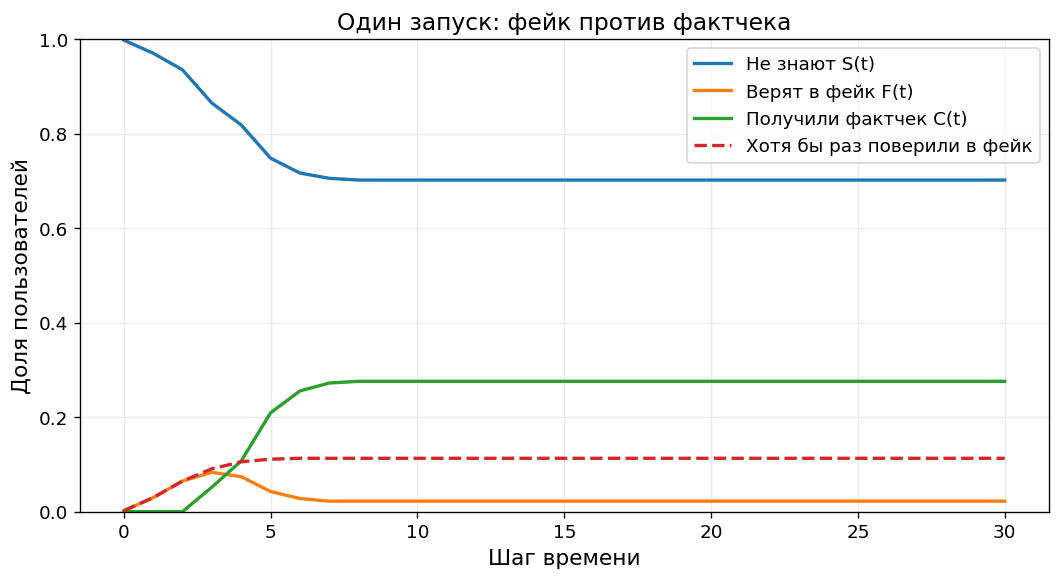

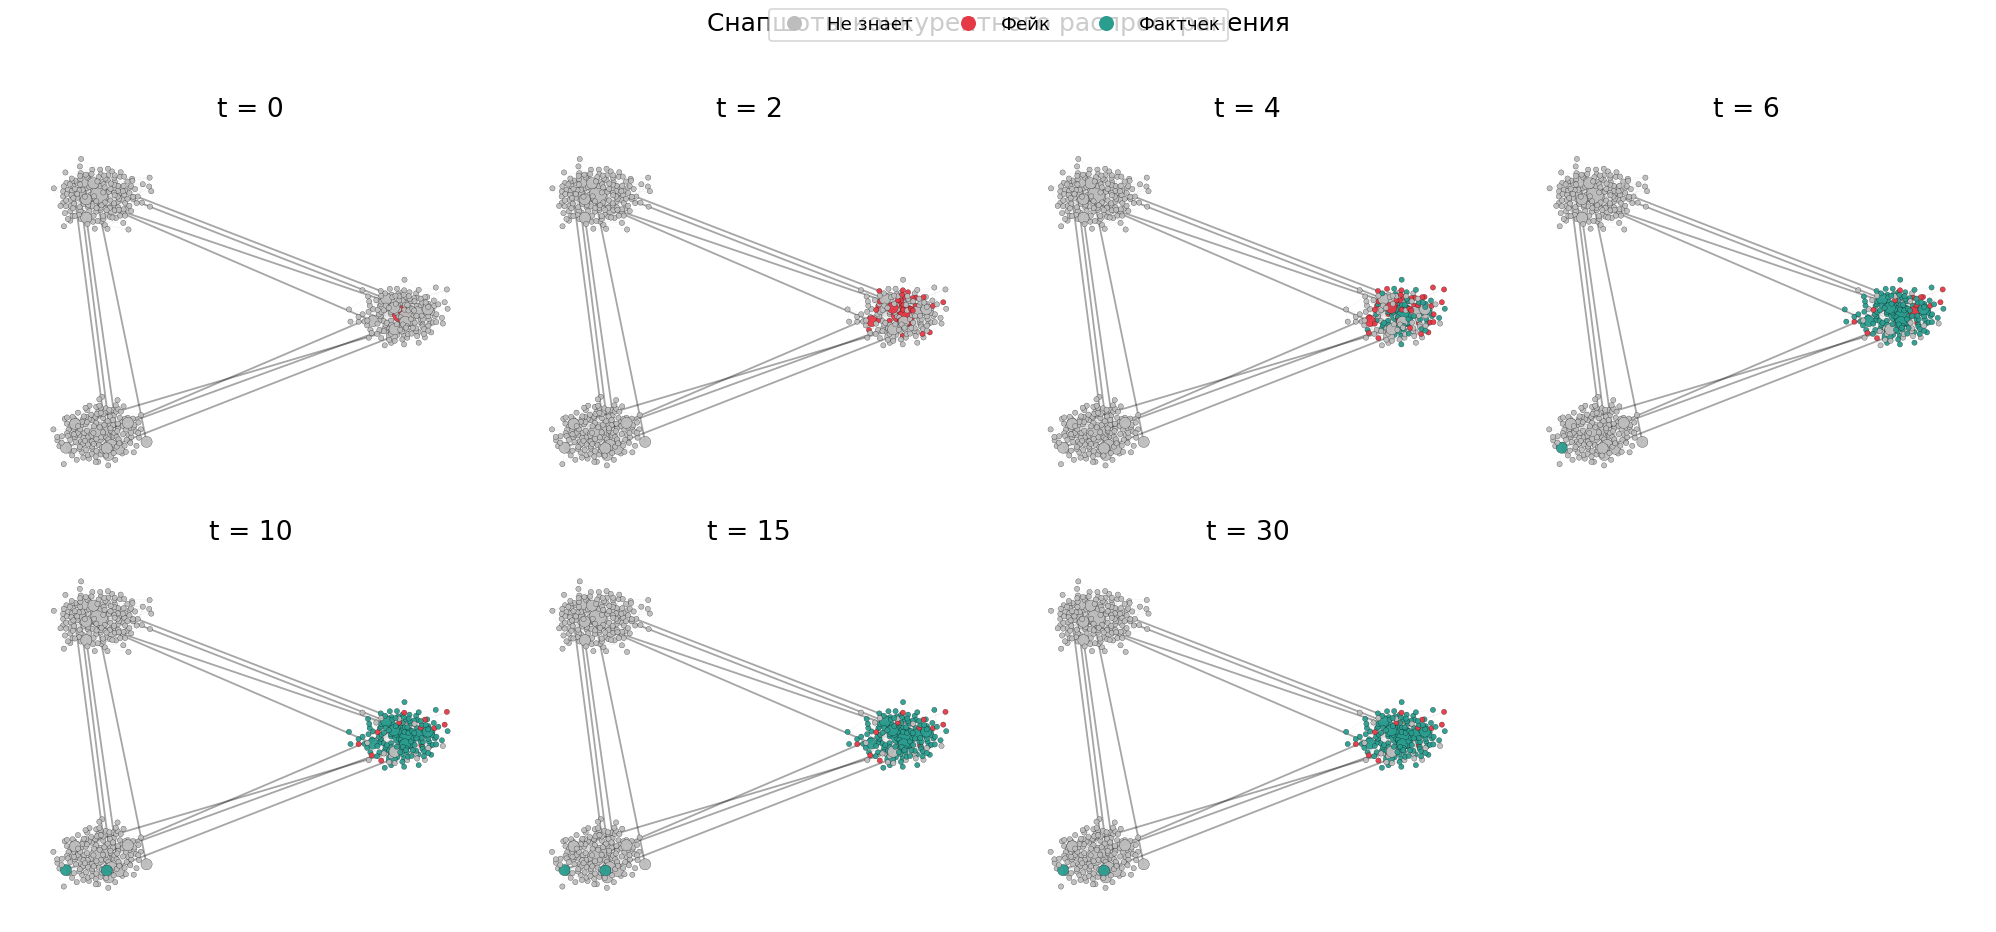

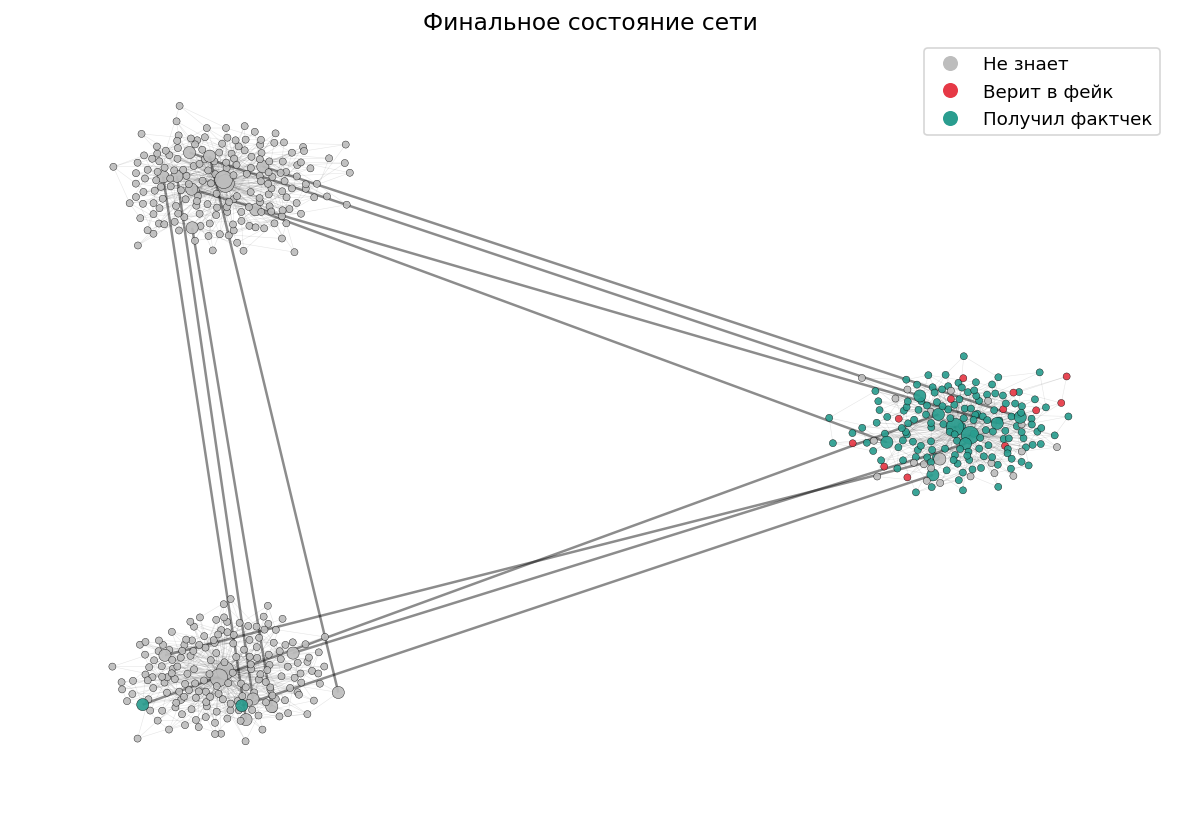

In [ ]:
local_rng = np.random.default_rng(SEED)

fake_seed = choose_fake_seed(
    G,
    fake_community=0,
    rng=local_rng,
)

check_seed = choose_factcheck_seed(
    G,
    strategy="influencer",
    fake_seed=fake_seed,
    fake_community=0,
    rng=local_rng,
)

result = run_simulation(
    G,
    fake_seed=fake_seed,
    check_seed=check_seed,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    outbreak_threshold=0.25,
    snapshot_steps=(0, 2, 4, 6, 10, 15, 30),
    seed=SEED,
)

print("Fake seed:", fake_seed)
print("Check seed:", check_seed)

display(
    pd.DataFrame([result["metrics"]])
    .T
    .rename(columns={0: "value"})
)

fig_dyn, ax_dyn = plot_dynamics(
    result["history"],
    title="Один запуск: фейк против фактчека",
)

fig_snapshots, axes_snapshots = plot_state_snapshots(
    G,
    result["snapshots"],
    pos,
    title="Снапшоты конкурентного распространения",
)

fig_final_state, ax_final_state = plot_network_state(
    G,
    result["states"],
    pos,
    title="Финальное состояние сети",
)

Это демонстрационный запуск модели: фейк стартует у инфлюенсера, а фактчек запускается через стратегию `influencer` с задержкой `delay = 3`.

Ключевые результаты текущего запуска:

| Метрика | Значение |
|---|---:|
| Финальная доля верящих в фейк | 0.0222 |
| Доля хотя бы раз поверивших в фейк | 0.1130 |
| Финальная доля получивших фактчек | 0.2759 |
| Пиковая доля фейка | 0.0833 |
| Время пика | 3 |
| Массовая инфодемия | нет |

Интерпретация графика: фейк быстро растет в первые шаги, но после запуска фактчека волна подавляется. Накопительная метрика `ever_fake` остается выше финального `fake_share`, потому что часть пользователей сначала поверила в фейк, а затем была переубеждена.

**Вывод для текста работы:** даже если фейк успевает создать ранний всплеск, таргетированный фактчек через инфлюенсера способен быстро снизить текущую долю пользователей, продолжающих верить в фейк.

## 9. Monte Carlo и сравнение стратегий

In [ ]:
def run_many(
    G,
    n_runs=150,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    strategy="influencer",
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
    show_progress=True,
):
    rng = np.random.default_rng(seed)
    rows = []

    iterator = range(n_runs)

    if show_progress:
        iterator = tqdm(iterator, desc=f"strategy={strategy}", leave=False)

    for run in iterator:
        run_seed = int(rng.integers(1, 1_000_000_000))
        run_rng = np.random.default_rng(run_seed)

        fake_seed = choose_fake_seed(
            G,
            fake_community=fake_community,
            rng=run_rng,
        )

        check_seed = choose_factcheck_seed(
            G,
            strategy=strategy,
            fake_seed=fake_seed,
            fake_community=fake_community,
            rng=run_rng,
        )

        sim = run_simulation(
            G,
            fake_seed=fake_seed,
            check_seed=check_seed,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            outbreak_threshold=outbreak_threshold,
            snapshot_steps=None,
            seed=run_seed,
        )

        row = sim["metrics"].copy()
        row["run"] = run
        row["strategy"] = strategy
        rows.append(row)

    return pd.DataFrame(rows)


def summarize_runs(df):
    return pd.DataFrame(
        [{
            "runs": len(df),
            "outbreak_probability": df["outbreak"].mean(),
            "mean_final_fake_share": df["final_fake_share"].mean(),
            "std_final_fake_share": df["final_fake_share"].std(),
            "mean_ever_fake_share": df["ever_fake_share"].mean(),
            "mean_final_checked_share": df["final_checked_share"].mean(),
            "mean_peak_fake_share": df["peak_fake_share"].mean(),
            "mean_time_to_peak": df["time_to_peak"].mean(),
        }]
    )


def compare_factcheck_strategies(
    G,
    strategies=(
        "none",
        "random",
        "same_community_random",
        "other_community_random",
        "bridge",
        "high_degree",
        "influencer",
    ),
    n_runs=150,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    parts = []

    for strategy in tqdm(strategies, desc="Сравнение стратегий"):
        df = run_many(
            G,
            n_runs=n_runs,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            strategy=strategy,
            fake_community=fake_community,
            outbreak_threshold=outbreak_threshold,
            seed=int(rng.integers(1, 1_000_000_000)),
            show_progress=False,
        )

        parts.append(df)

    return pd.concat(parts, ignore_index=True)


def summarize_strategy_results(results_df):
    summary = (
        results_df
        .groupby("strategy", as_index=False)
        .agg(
            runs=("run", "count"),
            outbreak_probability=("outbreak", "mean"),
            mean_final_fake_share=("final_fake_share", "mean"),
            std_final_fake_share=("final_fake_share", "std"),
            mean_ever_fake_share=("ever_fake_share", "mean"),
            mean_final_checked_share=("final_checked_share", "mean"),
            mean_peak_fake_share=("peak_fake_share", "mean"),
            mean_time_to_peak=("time_to_peak", "mean"),
        )
    )

    summary["strategy_ru"] = summary["strategy"].map(STRATEGY_RU).fillna(summary["strategy"])

    return summary.sort_values("mean_final_fake_share").reset_index(drop=True)


def plot_strategy_bar(summary_df, metric="mean_final_fake_share", title=None):
    data = summary_df.sort_values(metric).copy()
    labels = data["strategy"].map(STRATEGY_RU).fillna(data["strategy"])

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.bar(labels, data[metric])
    ax.set_xlabel("Стратегия запуска фактчека")
    ax.set_ylabel(metric)
    ax.set_title(title or f"Сравнение стратегий по метрике: {metric}")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    return fig, ax


def plot_strategy_boxplot(results_df, metric="final_fake_share", title=None):
    strategies = list(results_df["strategy"].drop_duplicates())

    data = [
        results_df.loc[results_df["strategy"] == s, metric].values
        for s in strategies
    ]

    labels = [STRATEGY_RU.get(s, s) for s in strategies]

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.boxplot(data, labels=labels, showmeans=True)

    ax.set_xlabel("Стратегия запуска фактчека")
    ax.set_ylabel(metric)
    ax.set_title(title or f"Разброс результатов по метрике: {metric}")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    return fig, ax


Здесь определены функции для массовых запусков модели.

Почему нужен Monte Carlo-подход: один запуск случайной модели может быть удачным или неудачным из-за случайных передач по ребрам. Чтобы получить устойчивые выводы, каждая конфигурация повторяется много раз (`n_runs = 150`), после чего считаются средние значения.

Основные функции:

- `run_many` — повторяет один сценарий много раз;
- `summarize_runs` — агрегирует результаты;
- `compare_factcheck_strategies` — сравнивает разные стратегии запуска фактчека;
- `plot_strategy_bar` и `plot_strategy_boxplot` — строят графики по стратегиям.

**Вывод для текста работы:** результаты исследования основаны не на единичной симуляции, а на серии повторных экспериментов, что снижает влияние случайности и делает сравнение стратегий надежнее.

## 10. Запуск сравнения стратегий фактчека

Сравнение стратегий:   0%|          | 0/7 [00:00<?, ?it/s]

,strategy,runs,outbreak_probability,mean_final_fake_share,std_final_fake_share,mean_ever_fake_share,mean_final_checked_share,mean_peak_fake_share,mean_time_to_peak,strategy_ru
0,influencer,300,0.003333,0.013778,0.021418,0.085920,0.697420,0.062198,3.260000,Инфлюенсер
1,same_community_random,300,0.080000,0.045778,0.062980,0.136556,0.562543,0.110877,5.293333,Случайный в исходной эхо-камере
2,high_degree,300,0.046667,0.060019,0.065046,0.142981,0.666043,0.135086,6.903333,Самый связный узел
3,bridge,300,0.046667,0.060710,0.065021,0.140414,0.661957,0.133790,6.790000,Мостовой узел
4,random,300,0.076667,0.066494,0.076922,0.143981,0.556358,0.132673,6.786667,Случайный узел
5,other_community_random,300,0.056667,0.074716,0.073449,0.145858,0.545951,0.142012,7.286667,Случайный в другой эхо-камере
6,none,300,0.120000,0.159093,0.070563,0.159093,0.000000,0.159093,8.620000,Без фактчека


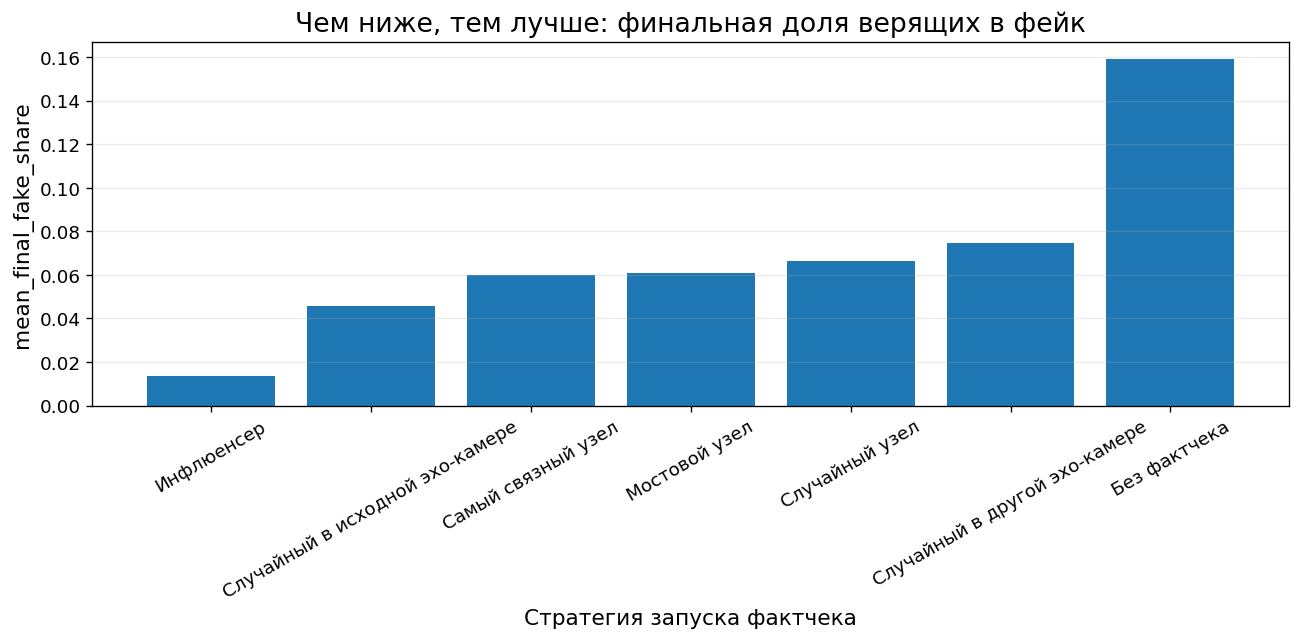

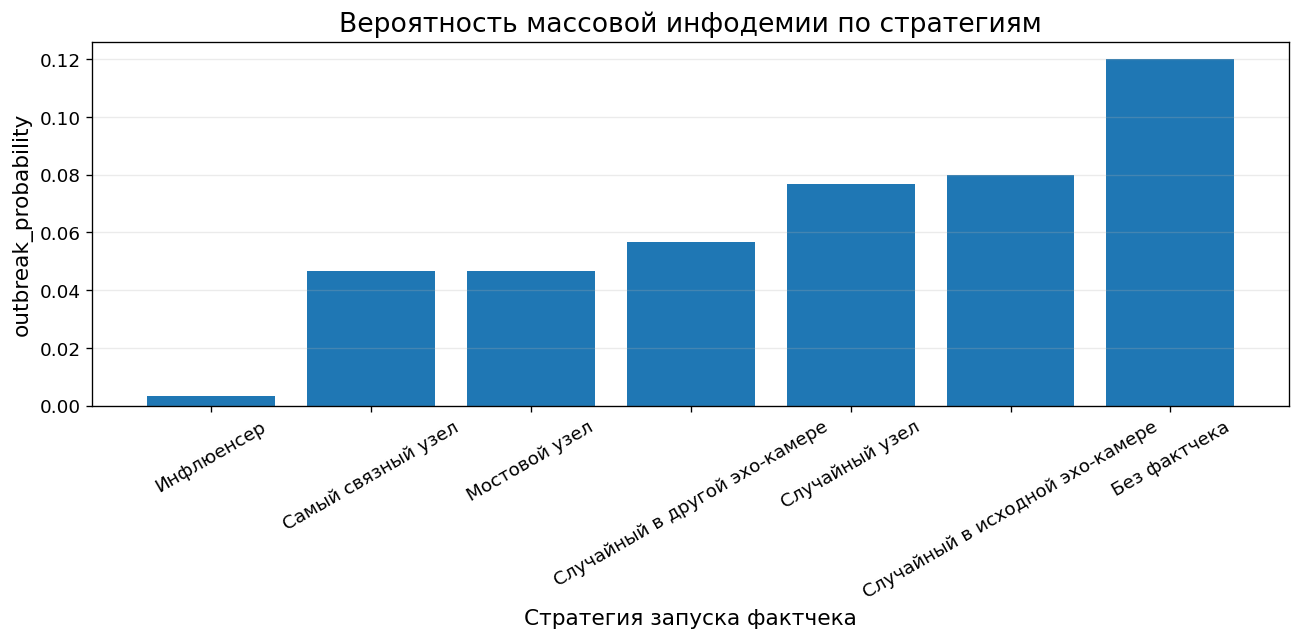

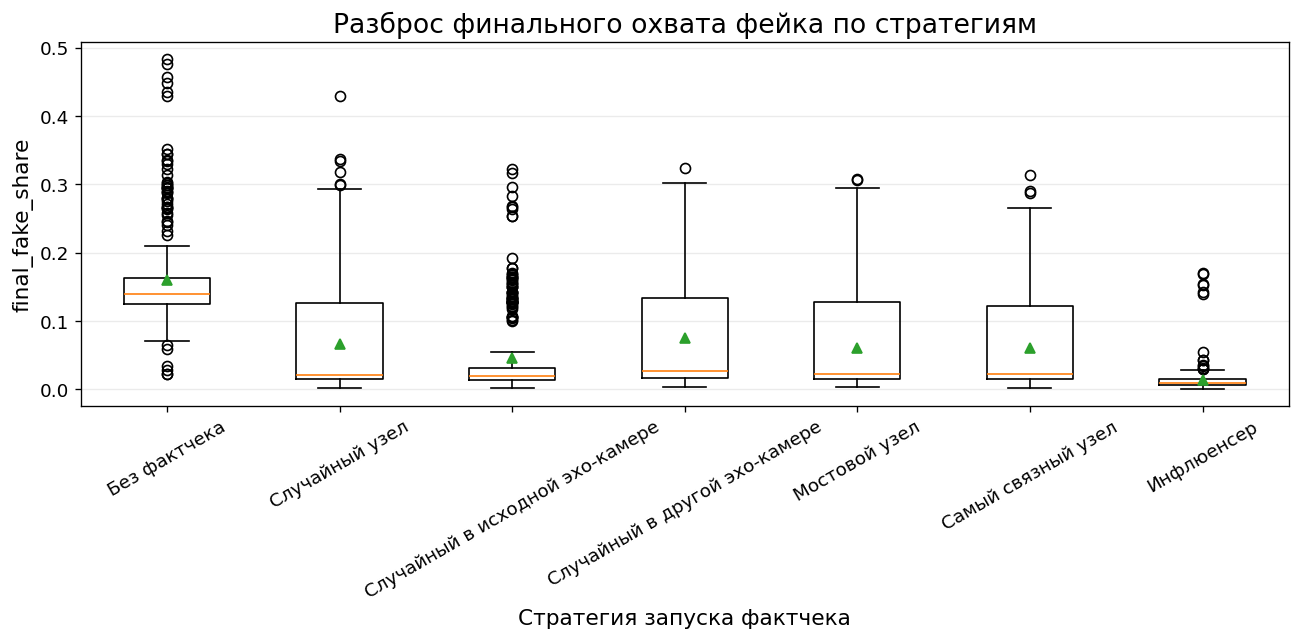

In [ ]:
STRATEGIES = [
    "none",
    "random",
    "same_community_random",
    "other_community_random",
    "bridge",
    "high_degree",
    "influencer",
]

strategy_results = compare_factcheck_strategies(
    G,
    strategies=STRATEGIES,
    n_runs=STRATEGY_RUNS,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=SEED,
)

strategy_summary = summarize_strategy_results(strategy_results)

display(strategy_summary)

fig_strategy_fake, ax_strategy_fake = plot_strategy_bar(
    strategy_summary,
    metric="mean_final_fake_share",
    title="Чем ниже, тем лучше: финальная доля верящих в фейк",
)

fig_strategy_outbreak, ax_strategy_outbreak = plot_strategy_bar(
    strategy_summary,
    metric="outbreak_probability",
    title="Вероятность массовой инфодемии по стратегиям",
)

fig_strategy_box, ax_strategy_box = plot_strategy_boxplot(
    strategy_results,
    metric="final_fake_share",
    title="Разброс финального охвата фейка по стратегиям",
)


Эта ячейка сравнивает стратегии запуска фактчека. Число повторов задается переменной `STRATEGY_RUNS` в начале ноутбука.

Сравниваются семь сценариев:

- отсутствие фактчека;
- случайный запуск фактчека;
- случайный узел в исходной эхо-камере;
- случайный узел в другой эхо-камере;
- мостовой узел;
- самый связный узел;
- инфлюенсер.

**Главный ожидаемый результат:** фактчек, направленный в инфлюенсера или другой структурно важный узел, должен снижать финальный охват фейка сильнее, чем случайный фактчек. Boxplot дополнительно показывает не только среднее значение, но и разброс: случайные стратегии обычно менее предсказуемы.


## 11. Функции для фазовых карт

In [ ]:
def scan_p_r_grid(
    G,
    p_values,
    r_values,
    w=2.0,
    delay=3,
    strategy="influencer",
    n_runs=HEATMAP_RUNS_PER_CELL,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
):
    """
    Сканирует сетку p x r.

    Возвращает:
    - DataFrame с результатами;
    - матрицу вероятности инфодемии.
    """
    rng = np.random.default_rng(seed)

    matrix = np.zeros((len(r_values), len(p_values)))
    records = []

    for i, r_value in enumerate(tqdm(r_values, desc="r grid")):
        for j, p_value in enumerate(p_values):
            df = run_many(
                G,
                n_runs=n_runs,
                p=float(p_value),
                w=float(w),
                r=float(r_value),
                delay=delay,
                steps=steps,
                strategy=strategy,
                fake_community=fake_community,
                outbreak_threshold=outbreak_threshold,
                seed=int(rng.integers(1, 1_000_000_000)),
                show_progress=False,
            )

            outbreak_probability = df["outbreak"].mean()
            matrix[i, j] = outbreak_probability

            records.append(
                {
                    "p": float(p_value),
                    "r": float(r_value),
                    "w": float(w),
                    "delay": delay,
                    "strategy": strategy,
                    "runs": n_runs,
                    "outbreak_probability": outbreak_probability,
                    "mean_final_fake_share": df["final_fake_share"].mean(),
                    "mean_ever_fake_share": df["ever_fake_share"].mean(),
                    "mean_peak_fake_share": df["peak_fake_share"].mean(),
                    "mean_final_checked_share": df["final_checked_share"].mean(),
                }
            )

    return pd.DataFrame(records), matrix


def scan_w_r_grid(
    G,
    w_values,
    r_values,
    p=0.08,
    delay=3,
    strategy="influencer",
    n_runs=HEATMAP_RUNS_PER_CELL,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
):
    """
    Сканирует сетку w x r.

    w — эмоциональность фейка.
    r — сила фактчека.
    """
    rng = np.random.default_rng(seed)

    matrix = np.zeros((len(r_values), len(w_values)))
    records = []

    for i, r_value in enumerate(tqdm(r_values, desc="r grid")):
        for j, w_value in enumerate(w_values):
            df = run_many(
                G,
                n_runs=n_runs,
                p=float(p),
                w=float(w_value),
                r=float(r_value),
                delay=delay,
                steps=steps,
                strategy=strategy,
                fake_community=fake_community,
                outbreak_threshold=outbreak_threshold,
                seed=int(rng.integers(1, 1_000_000_000)),
                show_progress=False,
            )

            outbreak_probability = df["outbreak"].mean()
            matrix[i, j] = outbreak_probability

            records.append(
                {
                    "w": float(w_value),
                    "r": float(r_value),
                    "p": float(p),
                    "delay": delay,
                    "strategy": strategy,
                    "runs": n_runs,
                    "outbreak_probability": outbreak_probability,
                    "mean_final_fake_share": df["final_fake_share"].mean(),
                    "mean_ever_fake_share": df["ever_fake_share"].mean(),
                    "mean_peak_fake_share": df["peak_fake_share"].mean(),
                    "mean_final_checked_share": df["final_checked_share"].mean(),
                }
            )

    return pd.DataFrame(records), matrix


def plot_heatmap(
    matrix,
    x_values,
    y_values,
    xlabel,
    ylabel,
    title,
    cbar_label="P(инфодемии)",
    boundary_level=0.5,
    cmap="magma",
):
    X, Y = np.meshgrid(x_values, y_values)

    fig, ax = plt.subplots(figsize=(9, 6.5))

    mesh = ax.pcolormesh(
        X,
        Y,
        matrix,
        shading="auto",
        vmin=0,
        vmax=1,
        cmap=cmap,
    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)

    # Граница фазового перехода: P(outbreak) = 0.5.
    if np.nanmin(matrix) <= boundary_level <= np.nanmax(matrix):
        contour = ax.contour(
            X,
            Y,
            matrix,
            levels=[boundary_level],
            linewidths=2,
        )

        ax.clabel(
            contour,
            inline=True,
            fontsize=10,
            fmt={boundary_level: f"порог {boundary_level:.1f}"},
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.15)

    plt.tight_layout()
    plt.show()

    return fig, ax


def estimate_critical_x(
    records_df,
    x_col,
    y_col,
    prob_col="outbreak_probability",
    level=0.5,
):
    """
    Для каждого значения y ищет минимальное x,
    при котором P(outbreak) >= level.

    Например:
    - x_col="p", y_col="r" дает критическое p для каждого r;
    - x_col="w", y_col="r" дает критическое w для каждого r.
    """
    rows = []

    for y_value, group in records_df.groupby(y_col):
        group = group.sort_values(x_col)
        crossed = group[group[prob_col] >= level]

        critical = np.nan if crossed.empty else crossed[x_col].iloc[0]

        rows.append(
            {
                y_col: y_value,
                f"critical_{x_col}": critical,
            }
        )

    return pd.DataFrame(rows)

Фазовая карта — это таблица экспериментов, где по одной оси меняется параметр `p`, по другой — `r`, а цвет показывает результат симуляции. В данном ноутбуке используются три типа карт:

| Карта | Что показывает |
|---|---|
| `outbreak_probability` | вероятность массовой инфодемии |
| `mean_final_fake_share` | средний финальный остаток фейка |
| `mean_peak_fake_share` | средний пиковый охват фейка |

Функция `estimate_critical_x` ищет критическую границу: минимальное значение параметра, при котором система переходит в массовое распространение.

**Вывод для текста работы:** фазовые карты позволяют перейти от отдельных симуляций к оценке перколяционного порога — границы между затуханием фейка и его массовым распространением.


## 12. Запуск фазовой карты `p × r`


r grid:   0%|          | 0/16 [00:00<?, ?it/s]

,p,r,w,delay,strategy,runs,outbreak_probability,mean_final_fake_share,mean_ever_fake_share,mean_peak_fake_share,mean_final_checked_share
0,0.020,0.05,2.0,3,influencer,100,0.0,0.009944,0.010870,0.010741,0.015519
1,0.031,0.05,2.0,3,influencer,100,0.0,0.016667,0.017704,0.017222,0.014907
2,0.041,0.05,2.0,3,influencer,100,0.0,0.025148,0.026685,0.025889,0.015759
3,0.052,0.05,2.0,3,influencer,100,0.0,0.035444,0.037926,0.036222,0.016222
4,0.063,0.05,2.0,3,influencer,100,0.0,0.061926,0.065204,0.062296,0.015889


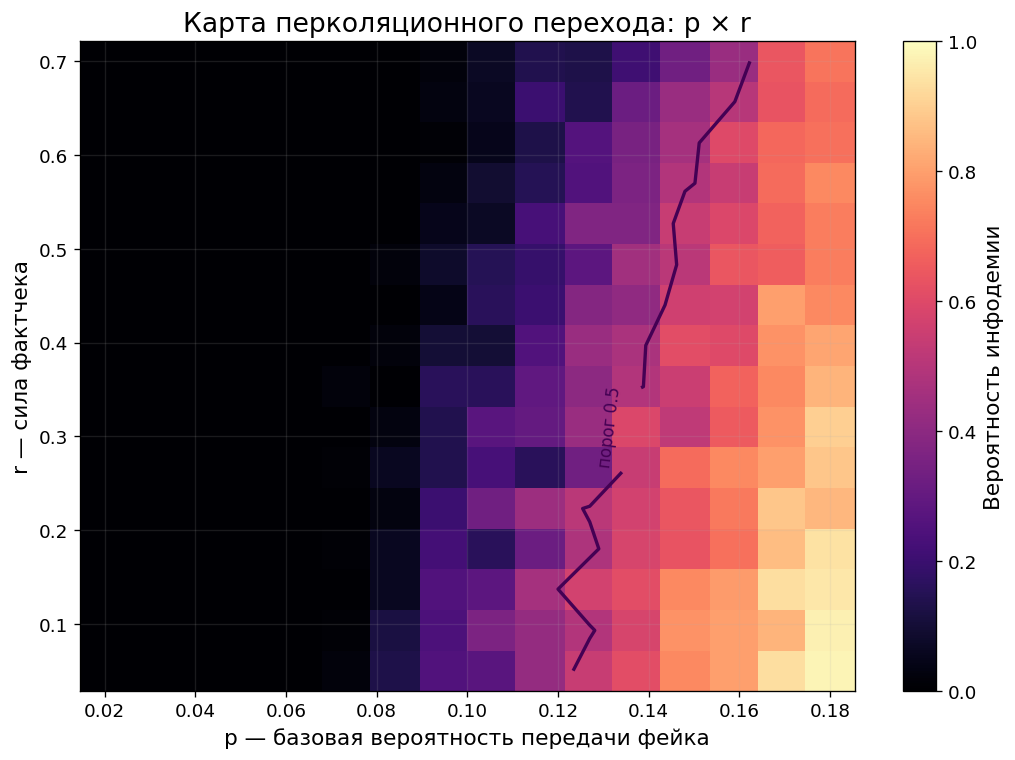

,r,critical_p
0,0.050,0.127
1,0.093,0.137
2,0.137,0.127
3,0.180,0.137
4,0.223,0.127
5,0.267,0.137
6,0.310,0.137
7,0.353,0.148
8,0.397,0.148
9,0.440,0.148


In [ ]:
# Для финального запуска используется более гладкая сетка HEATMAP_GRID_SIZE × HEATMAP_GRID_SIZE.
# Если нужно быстро проверить ноутбук, поставьте FAST_MODE = True в первой ячейке настроек.
p_values = np.round(np.linspace(0.02, 0.18, HEATMAP_GRID_SIZE), 3)
r_values = np.round(np.linspace(0.05, 0.70, HEATMAP_GRID_SIZE), 3)

pr_df, pr_matrix = scan_p_r_grid(
    G,
    p_values=p_values,
    r_values=r_values,
    w=2.0,
    delay=3,
    strategy="influencer",
    n_runs=HEATMAP_RUNS_PER_CELL,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=SEED,
)

display(pr_df.head())

fig_pr_heatmap, ax_pr_heatmap = plot_heatmap(
    pr_matrix,
    x_values=p_values,
    y_values=r_values,
    xlabel="p — базовая вероятность передачи фейка",
    ylabel="r — сила фактчека",
    title="Карта перколяционного перехода: p × r",
    cbar_label="Вероятность инфодемии",
    boundary_level=0.5,
)

critical_p_by_r = estimate_critical_x(
    pr_df,
    x_col="p",
    y_col="r",
    level=0.5,
)

display(critical_p_by_r)


Эта ячейка строит основную фазовую карту `p × r`.

- По оси `x` меняется базовая заразность фейка `p`.
- По оси `y` меняется сила фактчека `r`.
- Цвет показывает вероятность массовой инфодемии.

Размер сетки задается переменной `HEATMAP_GRID_SIZE`. В финальном режиме используется более гладкая сетка `16 × 16`, а в быстром режиме — `10 × 10`.

**Вывод для текста работы:** при росте `p` система переходит из докритического режима, где фейк затухает, в сверхкритический режим, где образуется крупный кластер зараженных. Увеличение `r` сдвигает систему обратно в безопасную область.


## 13. Дополнительные тепловые карты по `p × r`

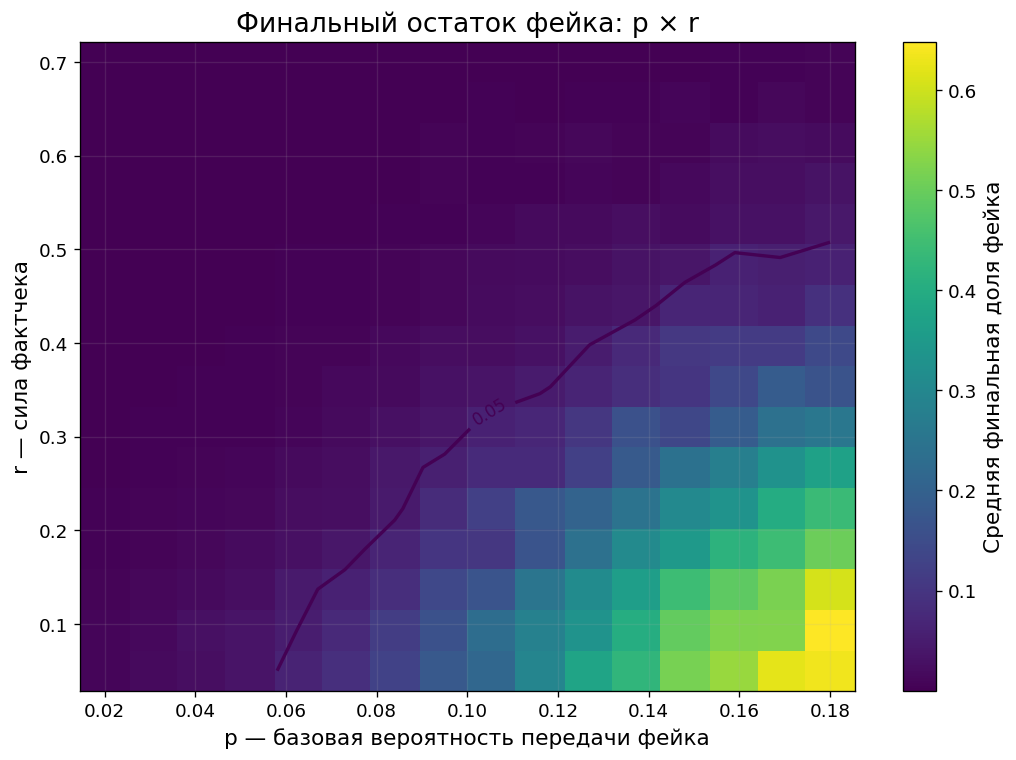

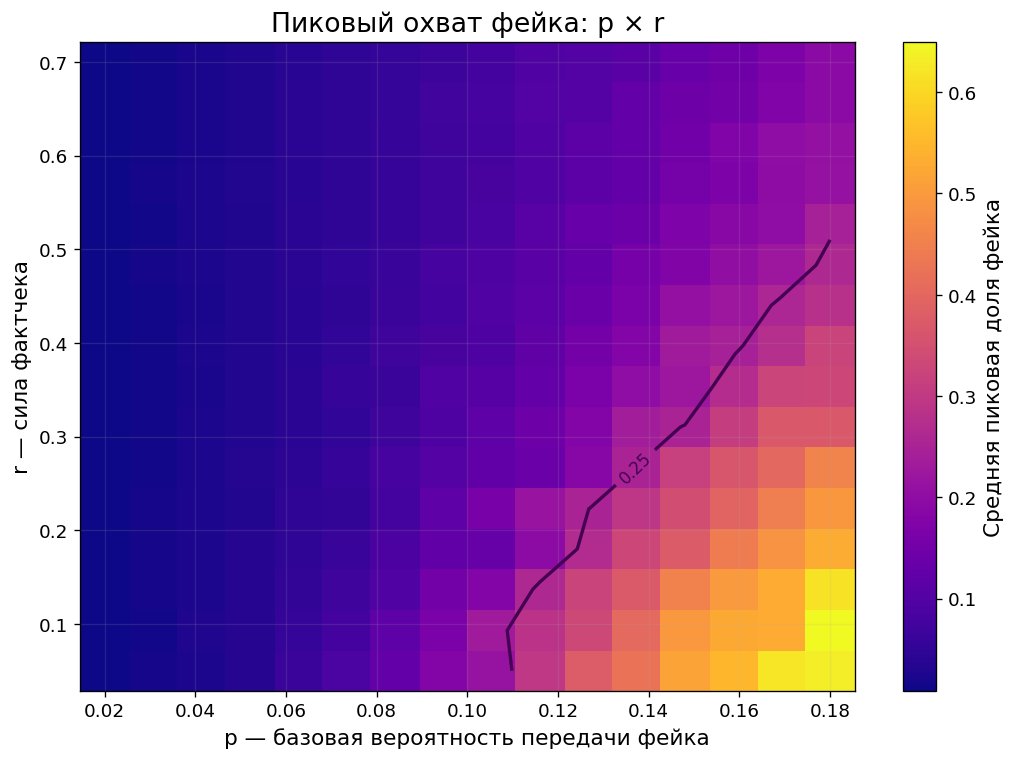

In [ ]:
def matrix_from_records(
    df,
    x_col,
    y_col,
    metric_col,
    x_values=None,
    y_values=None,
):
    pivot = df.pivot_table(
        index=y_col,
        columns=x_col,
        values=metric_col,
        aggfunc="mean",
    )

    if y_values is not None:
        pivot = pivot.reindex(y_values)

    if x_values is not None:
        pivot = pivot.reindex(columns=x_values)

    return pivot.values


def plot_metric_heatmap(
    matrix,
    x_values,
    y_values,
    xlabel,
    ylabel,
    title,
    cbar_label,
    boundary_level=None,
    cmap="viridis",
    vmin=None,
    vmax=None,
):
    X, Y = np.meshgrid(x_values, y_values)

    fig, ax = plt.subplots(figsize=(9, 6.5))

    mesh = ax.pcolormesh(
        X,
        Y,
        matrix,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)

    if boundary_level is not None:
        min_value = np.nanmin(matrix)
        max_value = np.nanmax(matrix)

        if min_value <= boundary_level <= max_value:
            contour = ax.contour(
                X,
                Y,
                matrix,
                levels=[boundary_level],
                linewidths=2,
            )

            ax.clabel(
                contour,
                inline=True,
                fontsize=10,
                fmt={boundary_level: f"{boundary_level:.2f}"},
            )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.15)

    plt.tight_layout()
    plt.show()

    return fig, ax


# Карта по финальной доле фейка.
# Это лучше показывает, насколько фактчек реально "убирает" фейк к концу симуляции.
pr_final_fake_matrix = matrix_from_records(
    pr_df,
    x_col="p",
    y_col="r",
    metric_col="mean_final_fake_share",
    x_values=p_values,
    y_values=r_values,
)

fig_pr_final_fake, ax_pr_final_fake = plot_metric_heatmap(
    pr_final_fake_matrix,
    x_values=p_values,
    y_values=r_values,
    xlabel="p — базовая вероятность передачи фейка",
    ylabel="r — сила фактчека",
    title="Финальный остаток фейка: p × r",
    cbar_label="Средняя финальная доля фейка",
    boundary_level=0.05,
    cmap="viridis",
)


# Карта по пику фейка.
# Это показывает, насколько большой была максимальная волна до подавления.
pr_peak_fake_matrix = matrix_from_records(
    pr_df,
    x_col="p",
    y_col="r",
    metric_col="mean_peak_fake_share",
    x_values=p_values,
    y_values=r_values,
)

fig_pr_peak_fake, ax_pr_peak_fake = plot_metric_heatmap(
    pr_peak_fake_matrix,
    x_values=p_values,
    y_values=r_values,
    xlabel="p — базовая вероятность передачи фейка",
    ylabel="r — сила фактчека",
    title="Пиковый охват фейка: p × r",
    cbar_label="Средняя пиковая доля фейка",
    boundary_level=0.25,
    cmap="plasma",
)

Эта ячейка строит две дополнительные тепловые карты на основе результатов `p × r`:

1. **Финальный остаток фейка** — сколько пользователей продолжает верить в фейк в конце симуляции.
2. **Пиковый охват фейка** — насколько большой была максимальная волна фейка до подавления.

Эти две карты нужно интерпретировать по-разному:

- финальный остаток показывает, насколько фактчек успешно «очищает» сеть к концу;
- пиковый охват показывает, какой ущерб фейк успел нанести до подавления.

На карте финального остатка видно: чем выше `p`, тем больше требуется `r`, чтобы удержать долю фейка ниже порога 5%. На карте пикового охвата видно: даже сильный фактчек может не полностью предотвратить ранний пик, если фейк распространяется быстро.

**Вывод для текста работы:** сила фактчека влияет не только на итоговую долю фейка, но и на форму волны. Для ранней профилактики важны одновременно высокая сила `r` и малая задержка запуска.

## 14. Фазовая карта `w × r`: эмоциональность фейка против силы фактчека

В презентационной постановке `w` отвечает за эмоциональную окраску фейка: чем выше эмоциональность, тем легче фейк распространяется. Поэтому отдельно строим карту `w × r`, где фиксируем базовую заразность `p`, но меняем эмоциональное усиление `w` и силу фактчека `r`.

Эта карта отвечает на вопрос: **сколько фактчекинга нужно, чтобы компенсировать эмоционально сильный фейк?**


r grid:   0%|          | 0/16 [00:00<?, ?it/s]

,w,r,p,delay,strategy,runs,outbreak_probability,mean_final_fake_share,mean_ever_fake_share,mean_peak_fake_share,mean_final_checked_share
0,1.00,0.05,0.08,3,influencer,100,0.0,0.024870,0.026648,0.025815,0.015815
1,1.15,0.05,0.08,3,influencer,100,0.0,0.029537,0.031500,0.030481,0.015722
2,1.29,0.05,0.08,3,influencer,100,0.0,0.038463,0.041333,0.039481,0.016556
3,1.44,0.05,0.08,3,influencer,100,0.0,0.045185,0.047426,0.045519,0.013648
4,1.59,0.05,0.08,3,influencer,100,0.0,0.054981,0.058000,0.055426,0.015426


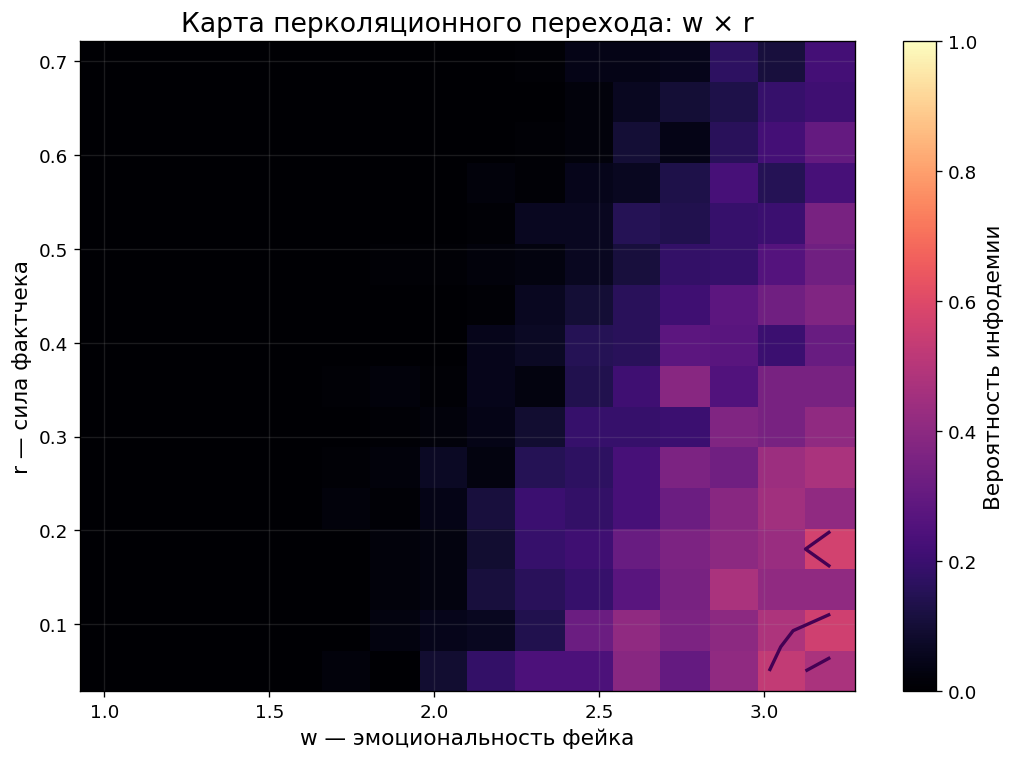

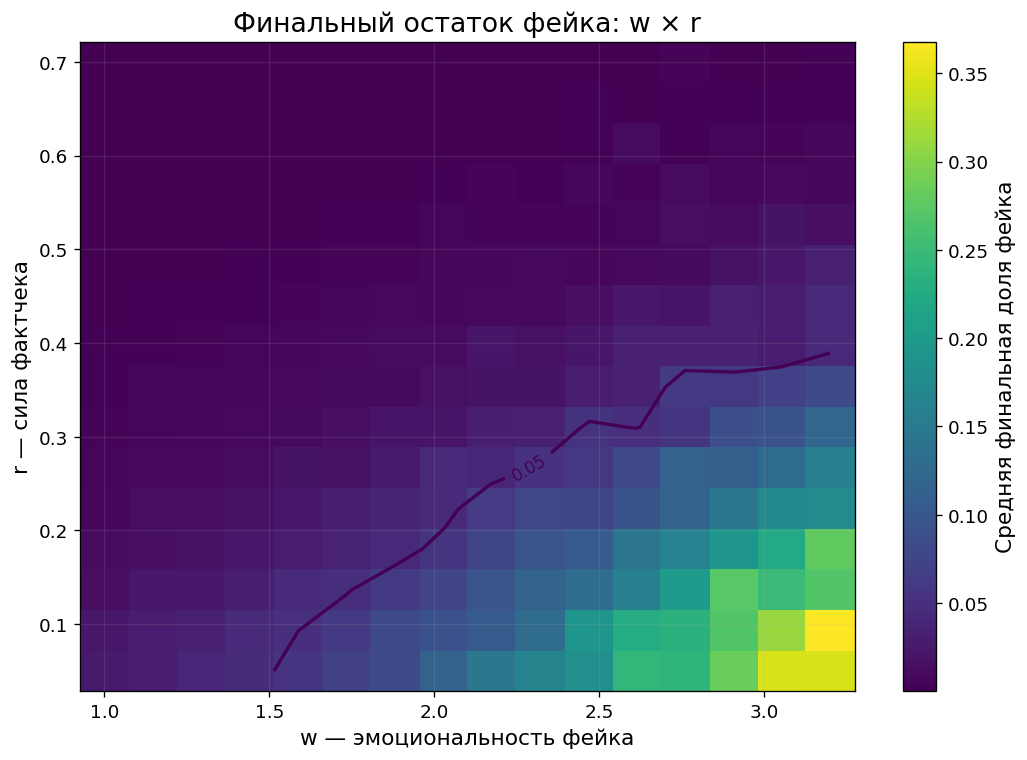

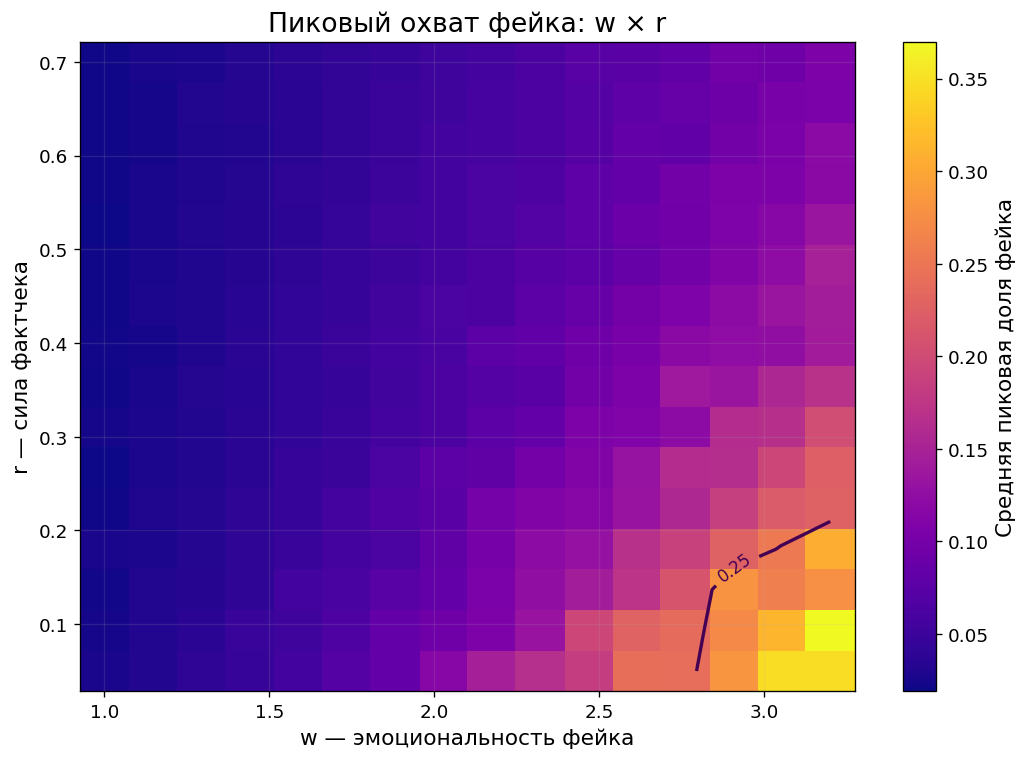

,r,critical_w
0,0.050,3.05
1,0.093,3.20
2,0.137,NaN
3,0.180,3.20
4,0.223,NaN
5,0.267,NaN
6,0.310,NaN
7,0.353,NaN
8,0.397,NaN
9,0.440,NaN


In [ ]:
w_values = np.round(np.linspace(1.0, 3.2, HEATMAP_GRID_SIZE), 2)
r_values_wr = np.round(np.linspace(0.05, 0.70, HEATMAP_GRID_SIZE), 3)

wr_df, wr_matrix = scan_w_r_grid(
    G,
    w_values=w_values,
    r_values=r_values_wr,
    p=0.08,
    delay=3,
    strategy="influencer",
    n_runs=WR_RUNS_PER_CELL,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=SEED + 1,
)

display(wr_df.head())

fig_wr_heatmap, ax_wr_heatmap = plot_heatmap(
    wr_matrix,
    x_values=w_values,
    y_values=r_values_wr,
    xlabel="w — эмоциональность фейка",
    ylabel="r — сила фактчека",
    title="Карта перколяционного перехода: w × r",
    cbar_label="Вероятность инфодемии",
    boundary_level=0.5,
)

wr_final_fake_matrix = matrix_from_records(
    wr_df,
    x_col="w",
    y_col="r",
    metric_col="mean_final_fake_share",
    x_values=w_values,
    y_values=r_values_wr,
)

fig_wr_final_fake, ax_wr_final_fake = plot_metric_heatmap(
    wr_final_fake_matrix,
    x_values=w_values,
    y_values=r_values_wr,
    xlabel="w — эмоциональность фейка",
    ylabel="r — сила фактчека",
    title="Финальный остаток фейка: w × r",
    cbar_label="Средняя финальная доля фейка",
    boundary_level=0.05,
    cmap="viridis",
)

wr_peak_fake_matrix = matrix_from_records(
    wr_df,
    x_col="w",
    y_col="r",
    metric_col="mean_peak_fake_share",
    x_values=w_values,
    y_values=r_values_wr,
)

fig_wr_peak_fake, ax_wr_peak_fake = plot_metric_heatmap(
    wr_peak_fake_matrix,
    x_values=w_values,
    y_values=r_values_wr,
    xlabel="w — эмоциональность фейка",
    ylabel="r — сила фактчека",
    title="Пиковый охват фейка: w × r",
    cbar_label="Средняя пиковая доля фейка",
    boundary_level=0.25,
    cmap="plasma",
)

critical_w_by_r = estimate_critical_x(
    wr_df,
    x_col="w",
    y_col="r",
    level=0.5,
)

display(critical_w_by_r)


**Как интерпретировать карту `w × r`:** если при росте `w` граница перехода сдвигается вверх, значит эмоционально более сильные фейки требуют большей силы фактчека. Это важный результат для текста работы, потому что он связывает математическую модель с тезисом о том, что эмоциональная окраска ускоряет распространение фейков.


## 15. Эксперимент с мостами между эхо-камерами


Bridge leakage scan:   0%|          | 0/7 [00:00<?, ?it/s]

,bridges_per_pair,runs,strategy,p,w,r,delay,mean_ever_fake_share,mean_ever_fake_outside_share,std_ever_fake_outside_share,...,mean_final_fake_outside_share,std_final_fake_outside_share,ci95_final_fake_outside_share,global_leakage_probability,global_leakage_ci95,mean_reached_communities,std_reached_communities,nodes,edges,bridge_nodes
0,0,300,none,0.1,2.2,0.0,3,0.200796,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,540,1918,0
1,1,300,none,0.1,2.2,0.0,3,0.221377,0.027778,0.092228,...,0.027778,0.092228,0.010437,0.086667,0.031837,1.106667,0.330130,540,1922,6
2,2,300,none,0.1,2.2,0.0,3,0.258093,0.084722,0.166584,...,0.084722,0.166584,0.018851,0.226667,0.047378,1.283333,0.551425,540,1927,12
3,4,300,none,0.1,2.2,0.0,3,0.292840,0.134296,0.208049,...,0.134296,0.208049,0.023543,0.330000,0.053210,1.456667,0.685338,540,1929,23
4,8,300,none,0.1,2.2,0.0,3,0.411660,0.314444,0.254350,...,0.314444,0.254350,0.028782,0.673333,0.053072,2.073333,0.818651,540,1943,47
5,12,300,none,0.1,2.2,0.0,3,0.469698,0.396139,0.249507,...,0.396139,0.249507,0.028234,0.773333,0.047378,2.323333,0.800578,540,1958,67
6,20,300,none,0.1,2.2,0.0,3,0.571469,0.549074,0.184754,...,0.549074,0.184754,0.020907,0.923333,0.030108,2.766667,0.571528,540,1980,109


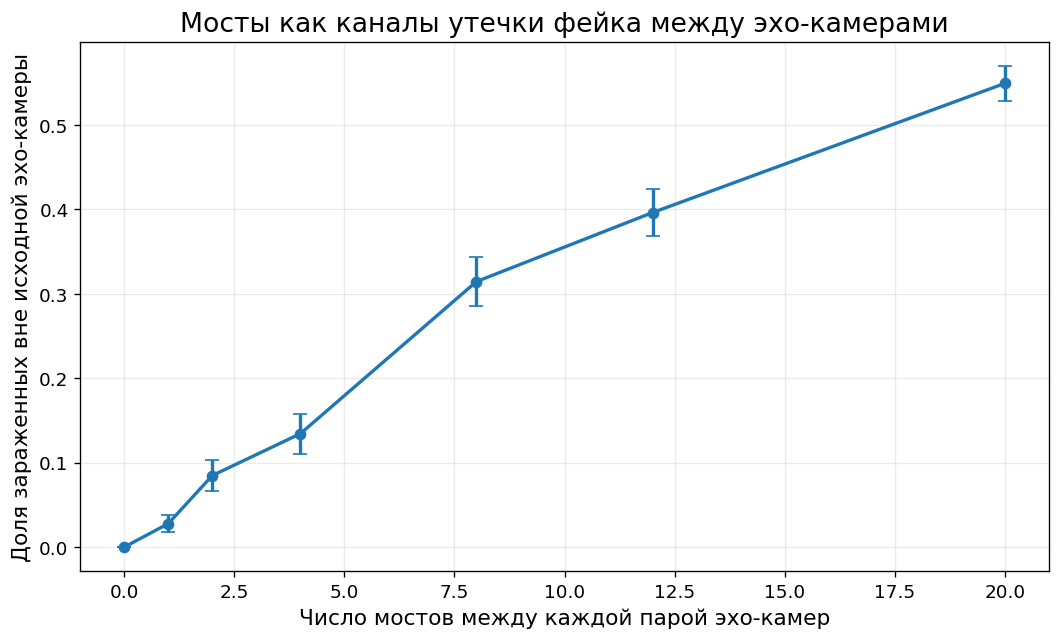

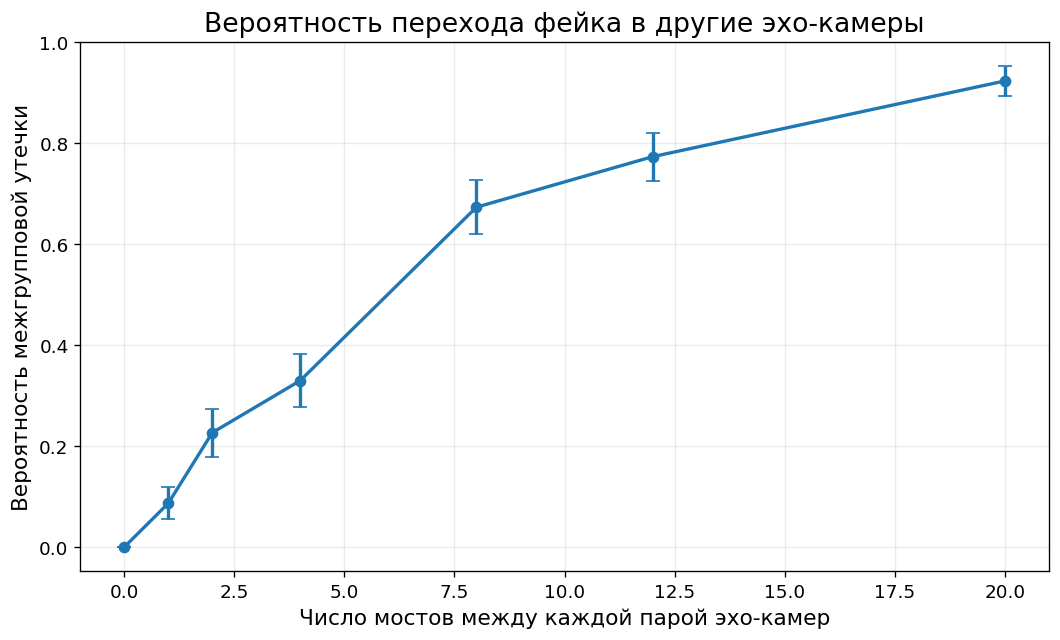

In [ ]:
def compute_leakage_metrics(
    G,
    sim,
    fake_seed,
    outside_threshold=0.03,
    community_reach_threshold=0.02,
):
    """
    Считает межгрупповое распространение фейка.

    outside_threshold:
    какая доля пользователей вне исходной эхо-камеры должна заразиться,
    чтобы считать, что произошла глобальная утечка.

    community_reach_threshold:
    какая доля пользователей внутри отдельной эхо-камеры должна заразиться,
    чтобы считать, что фейк реально достиг этой камеры.
    """
    source_community = G.nodes[fake_seed]["community"]

    ever_fake = sim["ever_fake"]
    states = sim["states"]

    all_nodes = list(G.nodes())

    outside_nodes = [
        n for n in all_nodes
        if G.nodes[n]["community"] != source_community
    ]

    if outside_nodes:
        ever_fake_outside_share = float(
            np.mean([ever_fake[n] for n in outside_nodes])
        )

        final_fake_outside_share = float(
            np.mean([states[n] == F for n in outside_nodes])
        )
    else:
        ever_fake_outside_share = 0.0
        final_fake_outside_share = 0.0

    communities = sorted(
        set(nx.get_node_attributes(G, "community").values())
    )

    community_ever_shares = {}

    for community in communities:
        nodes = [
            n for n in all_nodes
            if G.nodes[n]["community"] == community
        ]

        community_ever_shares[community] = float(
            np.mean([ever_fake[n] for n in nodes])
        )

    reached_communities = int(
        sum(
            share >= community_reach_threshold
            for share in community_ever_shares.values()
        )
    )

    global_leakage = int(
        ever_fake_outside_share >= outside_threshold
    )

    return {
        "source_community": source_community,
        "ever_fake_outside_share": ever_fake_outside_share,
        "final_fake_outside_share": final_fake_outside_share,
        "reached_communities": reached_communities,
        "global_leakage": global_leakage,
    }


def run_many_with_leakage(
    G,
    n_runs=150,
    p=0.10,
    w=2.2,
    r=0.0,
    delay=3,
    steps=30,
    strategy="none",
    fake_community=0,
    outbreak_threshold=0.25,
    outside_threshold=0.03,
    community_reach_threshold=0.02,
    seed=42,
    show_progress=True,
):
    rng = np.random.default_rng(seed)
    rows = []

    iterator = range(n_runs)

    if show_progress:
        iterator = tqdm(iterator, desc=f"leakage strategy={strategy}", leave=False)

    for run in iterator:
        run_seed = int(rng.integers(1, 1_000_000_000))
        run_rng = np.random.default_rng(run_seed)

        fake_seed = choose_fake_seed(
            G,
            fake_community=fake_community,
            rng=run_rng,
        )

        check_seed = choose_factcheck_seed(
            G,
            strategy=strategy,
            fake_seed=fake_seed,
            fake_community=fake_community,
            rng=run_rng,
        )

        sim = run_simulation(
            G,
            fake_seed=fake_seed,
            check_seed=check_seed,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            outbreak_threshold=outbreak_threshold,
            snapshot_steps=None,
            seed=run_seed,
        )

        row = sim["metrics"].copy()

        row.update(
            compute_leakage_metrics(
                G,
                sim,
                fake_seed=fake_seed,
                outside_threshold=outside_threshold,
                community_reach_threshold=community_reach_threshold,
            )
        )

        row["run"] = run
        row["strategy"] = strategy
        rows.append(row)

    return pd.DataFrame(rows)


def scan_bridge_leakage(
    bridge_values,
    base_network_kwargs,
    n_runs=150,
    p=0.10,
    w=2.2,
    r=0.0,
    delay=3,
    steps=30,
    strategy="none",
    fake_community=0,
    outbreak_threshold=0.25,
    outside_threshold=0.03,
    community_reach_threshold=0.02,
    seed=42,
):
    rng = np.random.default_rng(seed)
    records = []

    for bridges in tqdm(bridge_values, desc="Bridge leakage scan"):
        kwargs = base_network_kwargs.copy()
        kwargs["bridges_per_pair"] = int(bridges)
        kwargs["seed"] = int(rng.integers(1, 1_000_000_000))

        tmp_bundle = generate_echo_chamber_network(**kwargs)
        tmp_G = tmp_bundle.G

        df = run_many_with_leakage(
            tmp_G,
            n_runs=n_runs,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            strategy=strategy,
            fake_community=fake_community,
            outbreak_threshold=outbreak_threshold,
            outside_threshold=outside_threshold,
            community_reach_threshold=community_reach_threshold,
            seed=int(rng.integers(1, 1_000_000_000)),
            show_progress=False,
        )

        leakage_prob = df["global_leakage"].mean()
        outside_mean = df["ever_fake_outside_share"].mean()
        outside_std = df["ever_fake_outside_share"].std()
        final_outside_mean = df["final_fake_outside_share"].mean()
        final_outside_std = df["final_fake_outside_share"].std()

        records.append(
            {
                "bridges_per_pair": int(bridges),
                "runs": n_runs,
                "strategy": strategy,
                "p": p,
                "w": w,
                "r": r,
                "delay": delay,
                "mean_ever_fake_share": df["ever_fake_share"].mean(),
                "mean_ever_fake_outside_share": outside_mean,
                "std_ever_fake_outside_share": outside_std,
                "ci95_ever_fake_outside_share": ci95_from_std(outside_std, n_runs),
                "mean_final_fake_outside_share": final_outside_mean,
                "std_final_fake_outside_share": final_outside_std,
                "ci95_final_fake_outside_share": ci95_from_std(final_outside_std, n_runs),
                "global_leakage_probability": leakage_prob,
                "global_leakage_ci95": ci95_for_probability(leakage_prob, n_runs),
                "mean_reached_communities": df["reached_communities"].mean(),
                "std_reached_communities": df["reached_communities"].std(),
                "nodes": tmp_G.number_of_nodes(),
                "edges": tmp_G.number_of_edges(),
                "bridge_nodes": len(tmp_bundle.bridge_nodes),
            }
        )

    return pd.DataFrame(records)


def plot_bridge_leakage(
    bridge_df,
    metric,
    ylabel,
    title,
    ci_col=None,
):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    yerr = None
    if ci_col is not None and ci_col in bridge_df.columns:
        yerr = bridge_df[ci_col]

    ax.errorbar(
        bridge_df["bridges_per_pair"],
        bridge_df[metric],
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=4,
    )

    ax.set_xlabel("Число мостов между каждой парой эхо-камер")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    return fig, ax


bridge_values = [0, 1, 2, 4, 8, 12, 20]

# Здесь специально strategy="none":
# нам нужно сначала увидеть чистую роль мостов для фейка,
# без вмешательства сильного фактчека.
bridge_leakage_df = scan_bridge_leakage(
    bridge_values=bridge_values,
    base_network_kwargs=BASE_NETWORK_KWARGS,
    n_runs=BRIDGE_RUNS,
    p=0.10,
    w=2.2,
    r=0.0,
    delay=3,
    steps=30,
    strategy="none",
    fake_community=0,
    outbreak_threshold=0.25,
    outside_threshold=0.03,
    community_reach_threshold=0.02,
    seed=SEED,
)

display(bridge_leakage_df)

fig_bridge_leakage, ax_bridge_leakage = plot_bridge_leakage(
    bridge_leakage_df,
    metric="mean_ever_fake_outside_share",
    ci_col="ci95_ever_fake_outside_share",
    ylabel="Доля зараженных вне исходной эхо-камеры",
    title="Мосты как каналы утечки фейка между эхо-камерами",
)

fig_bridge_global_leakage, ax_bridge_global_leakage = plot_bridge_leakage(
    bridge_leakage_df,
    metric="global_leakage_probability",
    ci_col="global_leakage_ci95",
    ylabel="Вероятность межгрупповой утечки",
    title="Вероятность перехода фейка в другие эхо-камеры",
)


Эта ячейка проверяет роль межгрупповых мостов. В отличие от эксперимента со стратегиями, здесь фактчек специально отключен (`strategy="none"`), чтобы увидеть чистый эффект мостов как каналов распространения фейка.

Ключевые метрики:

- `mean_ever_fake_outside_share` — средняя доля пользователей вне исходной эхо-камеры, которые хотя бы раз поверили в фейк;
- `global_leakage_probability` — вероятность того, что фейк заметно перешел в другие эхо-камеры;
- `mean_reached_communities` — среднее число эхо-камер, достигнутых фейком.

В этой версии добавлены 95% доверительные интервалы для ключевых метрик. Это важно, потому что график теперь показывает не только среднюю тенденцию, но и неопределенность оценки.

**Вывод для текста работы:** мосты между эхо-камерами работают как каналы глобальной перколяции. Пока мостов мало, фейк остается локальным; при росте числа мостов вероятность перехода в другие сообщества резко возрастает.


## 16. Доверительные интервалы для стратегий


In [ ]:
def strategy_summary_with_ci(strategy_results):
    summary = (
        strategy_results
        .groupby("strategy", as_index=False)
        .agg(
            runs=("run", "count"),
            mean_final_fake_share=("final_fake_share", "mean"),
            std_final_fake_share=("final_fake_share", "std"),
            outbreak_probability=("outbreak", "mean"),
            mean_ever_fake_share=("ever_fake_share", "mean"),
            mean_peak_fake_share=("peak_fake_share", "mean"),
            mean_final_checked_share=("final_checked_share", "mean"),
            mean_time_to_peak=("time_to_peak", "mean"),
        )
    )

    summary["final_fake_ci95"] = summary.apply(
        lambda row: ci95_from_std(row["std_final_fake_share"], row["runs"]),
        axis=1,
    )

    summary["outbreak_ci95"] = summary.apply(
        lambda row: ci95_for_probability(row["outbreak_probability"], row["runs"]),
        axis=1,
    )

    if "none" in set(summary["strategy"]):
        baseline = float(
            summary.loc[
                summary["strategy"] == "none",
                "mean_final_fake_share"
            ].iloc[0]
        )

        summary["reduction_vs_no_factcheck_pct"] = (
            100 * (1 - summary["mean_final_fake_share"] / baseline)
        )
    else:
        summary["reduction_vs_no_factcheck_pct"] = np.nan

    summary["strategy_ru"] = summary["strategy"].map(STRATEGY_RU).fillna(summary["strategy"])

    return summary.sort_values("mean_final_fake_share").reset_index(drop=True)


strategy_summary_ci = strategy_summary_with_ci(strategy_results)

display(strategy_summary_ci)


,strategy,runs,mean_final_fake_share,std_final_fake_share,outbreak_probability,mean_ever_fake_share,mean_peak_fake_share,mean_final_checked_share,mean_time_to_peak,final_fake_ci95,outbreak_ci95,reduction_vs_no_factcheck_pct,strategy_ru
0,influencer,300,0.013778,0.021418,0.003333,0.085920,0.062198,0.697420,3.260000,0.002424,0.006522,91.339774,Инфлюенсер
1,same_community_random,300,0.045778,0.062980,0.080000,0.136556,0.110877,0.562543,5.293333,0.007127,0.030700,71.225701,Случайный в исходной эхо-камере
2,high_degree,300,0.060019,0.065046,0.046667,0.142981,0.135086,0.666043,6.903333,0.007361,0.023868,62.274473,Самый связный узел
3,bridge,300,0.060710,0.065021,0.046667,0.140414,0.133790,0.661957,6.790000,0.007358,0.023868,61.839910,Мостовой узел
4,random,300,0.066494,0.076922,0.076667,0.143981,0.132673,0.556358,6.786667,0.008704,0.030108,58.204322,Случайный узел
5,other_community_random,300,0.074716,0.073449,0.056667,0.145858,0.142012,0.545951,7.286667,0.008312,0.026163,53.036123,Случайный в другой эхо-камере
6,none,300,0.159093,0.070563,0.120000,0.159093,0.159093,0.000000,8.620000,0.007985,0.036773,0.000000,Без фактчека




Здесь к результатам сравнения стратегий добавляются 95% доверительные интервалы.

Доверительный интервал показывает, насколько устойчиво оценено среднее значение. Если стратегия имеет маленькое среднее и маленький интервал, значит она не только эффективна, но и стабильна.

Также рассчитывается показатель:

$$
\text{reduction} = 100 \cdot \left(1 - \frac{\text{final fake share with strategy}}{\text{final fake share without factcheck}}\right)
$$

Он показывает, насколько стратегия снижает финальный охват фейка относительно сценария без фактчека.

**Вывод для текста работы:** стратегия `influencer` снижает финальную долю фейка примерно на 92% относительно отсутствия фактчека; это самый сильный результат среди проверенных стратегий.

## 17. Финальные графики стратегий


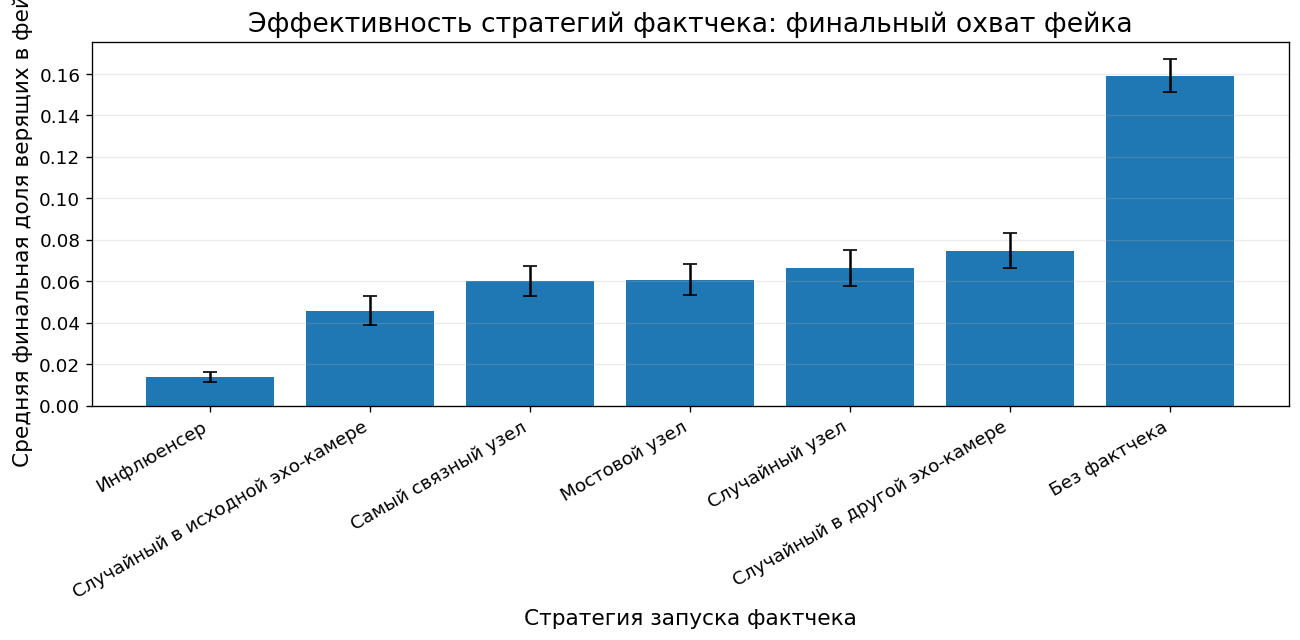

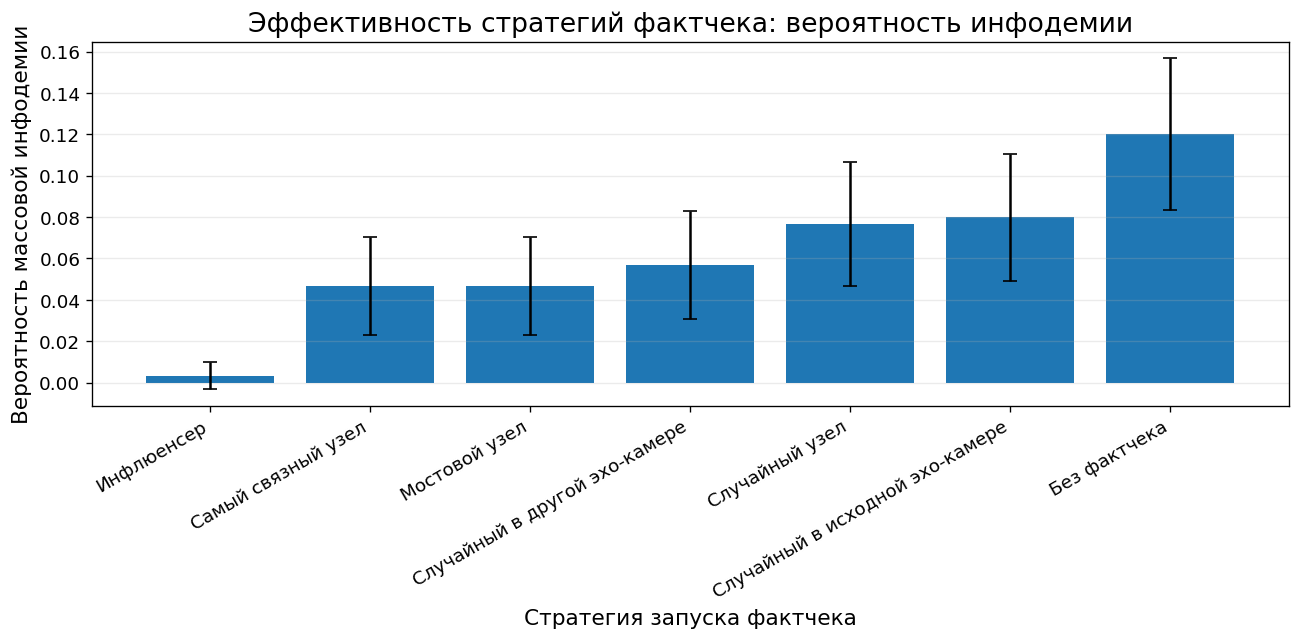

In [ ]:
def plot_strategy_metric_with_ci(
    summary_df,
    metric,
    ci_col,
    ylabel,
    title,
):
    data = summary_df.sort_values(metric).copy()

    x = np.arange(len(data))

    fig, ax = plt.subplots(figsize=(11, 5.5))

    ax.bar(
        x,
        data[metric],
        yerr=data[ci_col],
        capsize=4,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(data["strategy_ru"], rotation=30, ha="right")

    ax.set_ylabel(ylabel)
    ax.set_xlabel("Стратегия запуска фактчека")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    return fig, ax


fig_strategy_final_ci, ax_strategy_final_ci = plot_strategy_metric_with_ci(
    strategy_summary_ci,
    metric="mean_final_fake_share",
    ci_col="final_fake_ci95",
    ylabel="Средняя финальная доля верящих в фейк",
    title="Эффективность стратегий фактчека: финальный охват фейка",
)


fig_strategy_outbreak_ci, ax_strategy_outbreak_ci = plot_strategy_metric_with_ci(
    strategy_summary_ci,
    metric="outbreak_probability",
    ci_col="outbreak_ci95",
    ylabel="Вероятность массовой инфодемии",
    title="Эффективность стратегий фактчека: вероятность инфодемии",
)

## 18. Таблица эффективности стратегий


In [ ]:
effectiveness_table = strategy_summary_ci[
    [
        "strategy_ru",
        "runs",
        "mean_final_fake_share",
        "outbreak_probability",
        "mean_peak_fake_share",
        "reduction_vs_no_factcheck_pct",
    ]
].copy()

effectiveness_table = effectiveness_table.rename(
    columns={
        "strategy_ru": "Стратегия",
        "runs": "Число запусков",
        "mean_final_fake_share": "Финальная доля фейка",
        "outbreak_probability": "Вероятность инфодемии",
        "mean_peak_fake_share": "Пиковая доля фейка",
        "reduction_vs_no_factcheck_pct": "Снижение относительно no factcheck, %",
    }
)

display(effectiveness_table)

,Стратегия,Число запусков,Финальная доля фейка,Вероятность инфодемии,Пиковая доля фейка,"Снижение относительно no factcheck, %"
0,Инфлюенсер,300,0.013778,0.003333,0.062198,91.339774
1,Случайный в исходной эхо-камере,300,0.045778,0.080000,0.110877,71.225701
2,Самый связный узел,300,0.060019,0.046667,0.135086,62.274473
3,Мостовой узел,300,0.060710,0.046667,0.133790,61.839910
4,Случайный узел,300,0.066494,0.076667,0.132673,58.204322
5,Случайный в другой эхо-камере,300,0.074716,0.056667,0.142012,53.036123
6,Без фактчека,300,0.159093,0.120000,0.159093,0.000000


Эта таблица автоматически считает эффективность стратегий относительно сценария `Без фактчека`.

Главные колонки:

- `Финальная доля фейка` — сколько пользователей продолжает верить в фейк в конце симуляции;
- `Вероятность инфодемии` — как часто фейк превысил заданный порог;
- `Пиковая доля фейка` — максимальный размер волны во время распространения;
- `Снижение относительно no factcheck, %` — насколько стратегия уменьшает финальный охват фейка по сравнению с отсутствием фактчека.

**Вывод для текста работы:** наиболее эффективна не массовая случайная реакция, а точечное воздействие на структурно важные узлы сети. Таблица позволяет перевести этот вывод в численную форму.


## 19. Чувствительность к порогу инфодемии


,strategy,strategy_ru,threshold,metric_col,runs,outbreak_probability,outbreak_ci95
0,bridge,Мостовой узел,0.10,ever_fake_share,300,0.910000,0.032385
1,bridge,Мостовой узел,0.15,ever_fake_share,300,0.313333,0.052489
2,bridge,Мостовой узел,0.20,ever_fake_share,300,0.056667,0.026163
3,bridge,Мостовой узел,0.25,ever_fake_share,300,0.046667,0.023868
4,bridge,Мостовой узел,0.30,ever_fake_share,300,0.016667,0.014487
5,bridge,Мостовой узел,0.35,ever_fake_share,300,0.000000,0.000000
6,high_degree,Самый связный узел,0.10,ever_fake_share,300,0.926667,0.029499
7,high_degree,Самый связный узел,0.15,ever_fake_share,300,0.333333,0.053344
8,high_degree,Самый связный узел,0.20,ever_fake_share,300,0.083333,0.031276
9,high_degree,Самый связный узел,0.25,ever_fake_share,300,0.046667,0.023868


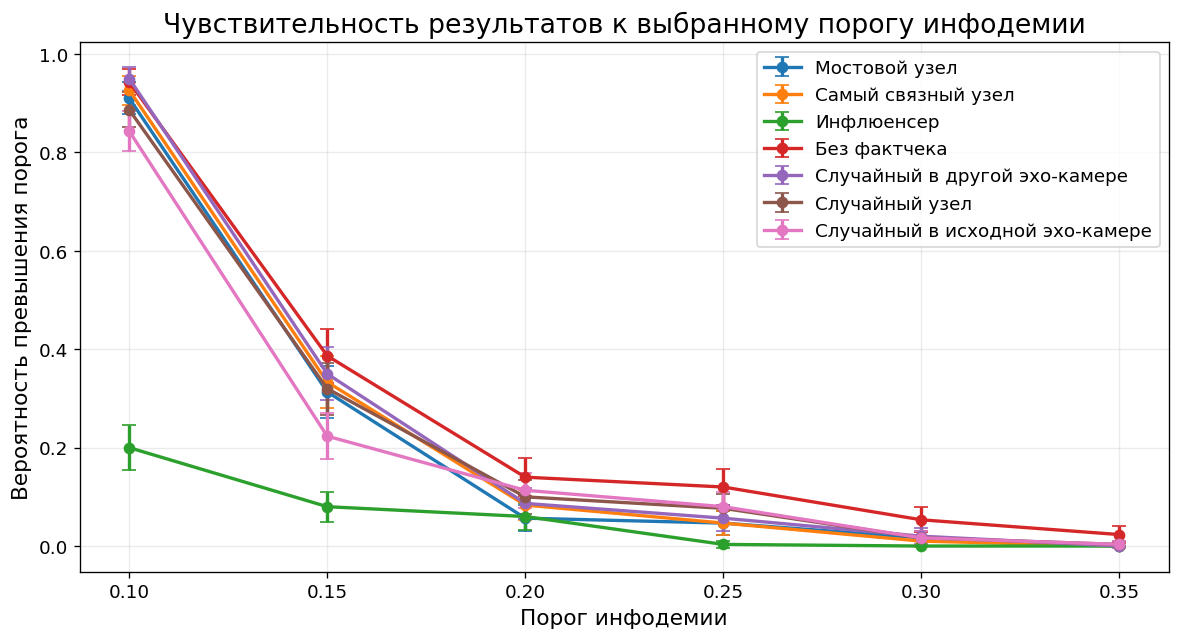

In [ ]:
def threshold_sensitivity_by_strategy(
    results_df,
    thresholds=(0.10, 0.15, 0.20, 0.25, 0.30, 0.35),
    metric_col="ever_fake_share",
):
    records = []

    for strategy, group in results_df.groupby("strategy"):
        for threshold in thresholds:
            probability = float((group[metric_col] >= threshold).mean())
            n = len(group)
            records.append(
                {
                    "strategy": strategy,
                    "strategy_ru": STRATEGY_RU.get(strategy, strategy),
                    "threshold": float(threshold),
                    "metric_col": metric_col,
                    "runs": n,
                    "outbreak_probability": probability,
                    "outbreak_ci95": ci95_for_probability(probability, n),
                }
            )

    return pd.DataFrame(records)


def plot_threshold_sensitivity(threshold_df):
    fig, ax = plt.subplots(figsize=(10, 5.5))

    for strategy in threshold_df["strategy"].drop_duplicates():
        subset = threshold_df[threshold_df["strategy"] == strategy].sort_values("threshold")
        ax.errorbar(
            subset["threshold"],
            subset["outbreak_probability"],
            yerr=subset["outbreak_ci95"],
            marker="o",
            linewidth=2,
            capsize=4,
            label=STRATEGY_RU.get(strategy, strategy),
        )

    ax.set_xlabel("Порог инфодемии")
    ax.set_ylabel("Вероятность превышения порога")
    ax.set_title("Чувствительность результатов к выбранному порогу инфодемии")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

    return fig, ax


threshold_sensitivity_df = threshold_sensitivity_by_strategy(
    strategy_results,
    thresholds=(0.10, 0.15, 0.20, 0.25, 0.30, 0.35),
    metric_col="ever_fake_share",
)

display(threshold_sensitivity_df)

fig_threshold_sensitivity, ax_threshold_sensitivity = plot_threshold_sensitivity(
    threshold_sensitivity_df
)


**Как читать результат:** если порядок стратегий сохраняется при разных порогах, значит вывод о лучшей стратегии не зависит от одного произвольно выбранного значения `outbreak_threshold`. Это усиливает надежность выводов.


## 20. Проверка устойчивости результатов на разных сетях


Robustness networks:   0%|          | 0/5 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/5 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/5 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/5 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/5 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/5 [00:00<?, ?it/s]

,strategy,networks,mean_final_fake_share,std_final_fake_share_across_networks,outbreak_probability,std_outbreak_across_networks,mean_peak_fake_share,mean_ever_fake_share,final_fake_ci95_networks,outbreak_ci95_networks,strategy_ru
0,influencer,5,0.016691,0.001731,0.023333,0.014907,0.066852,0.092556,0.001517,0.013067,Инфлюенсер
1,bridge,5,0.038877,0.025658,0.040000,0.019003,0.112253,0.132475,0.022490,0.016657,Мостовой узел
2,high_degree,5,0.055117,0.015210,0.040000,0.041833,0.130809,0.140043,0.013332,0.036668,Самый связный узел
3,random,5,0.069364,0.004834,0.076667,0.034561,0.137086,0.151105,0.004237,0.030294,Случайный узел
4,none,5,0.169735,0.011704,0.166667,0.055277,0.169735,0.169735,0.010259,0.048452,Без фактчека


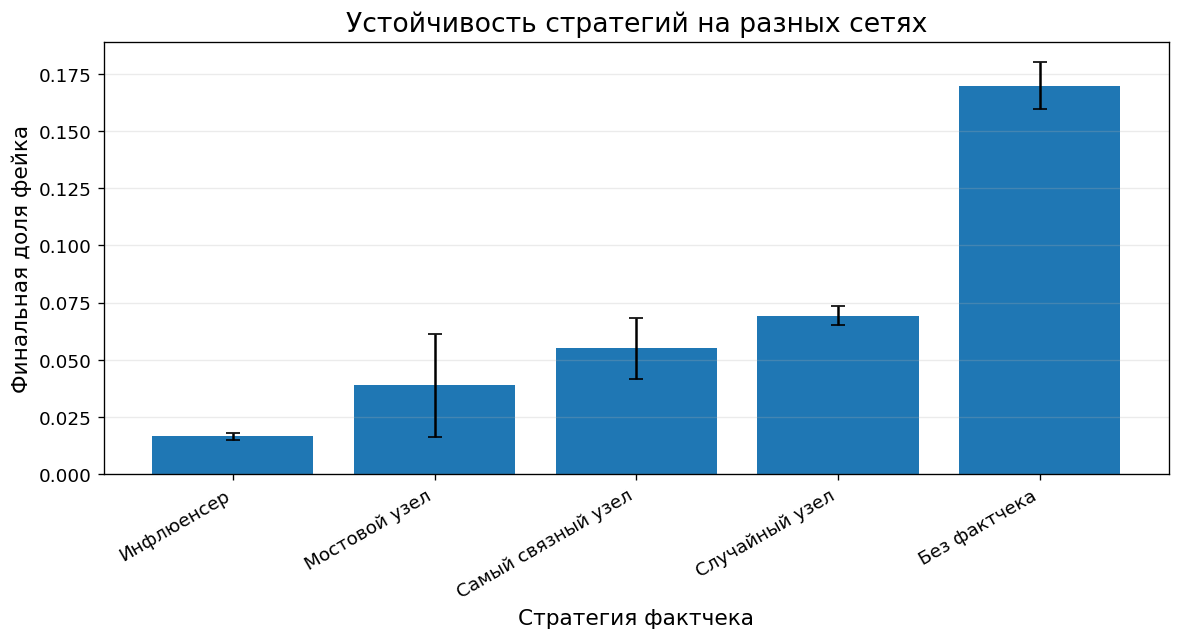

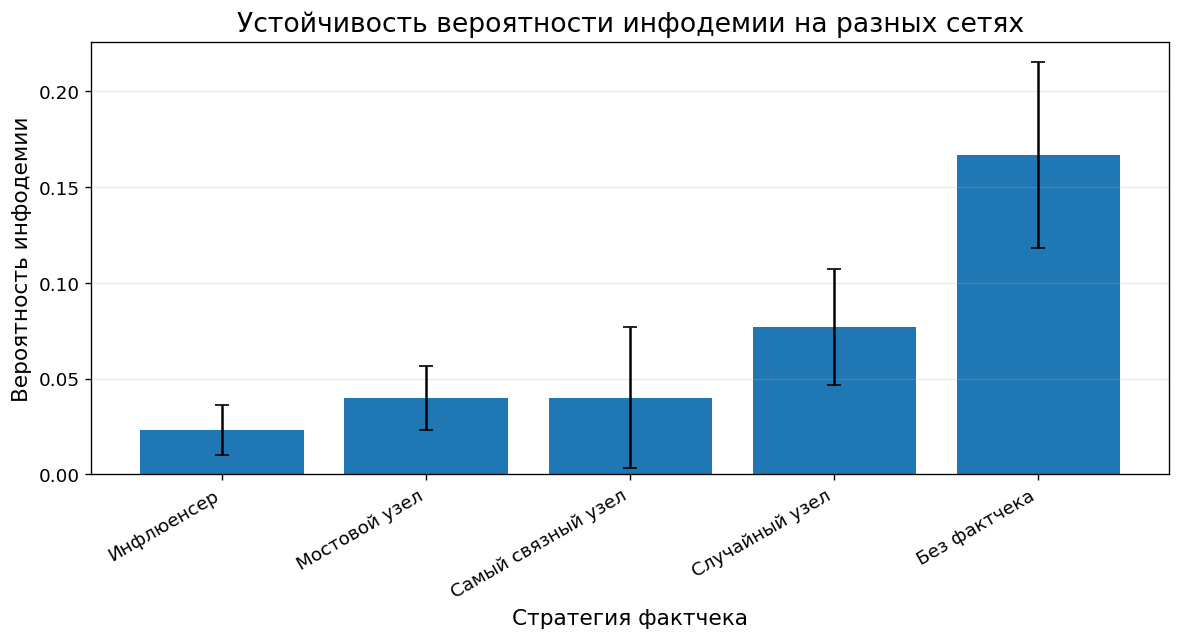

In [ ]:
def compare_strategies_across_networks(
    base_network_kwargs,
    network_seeds,
    strategies=("none", "random", "bridge", "high_degree", "influencer"),
    runs_per_network=60,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    parts = []

    for network_id, network_seed in enumerate(tqdm(network_seeds, desc="Robustness networks")):
        kwargs = base_network_kwargs.copy()
        kwargs["seed"] = int(network_seed)
        tmp_bundle = generate_echo_chamber_network(**kwargs)
        tmp_G = tmp_bundle.G

        df = compare_factcheck_strategies(
            tmp_G,
            strategies=strategies,
            n_runs=runs_per_network,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            fake_community=fake_community,
            outbreak_threshold=outbreak_threshold,
            seed=int(rng.integers(1, 1_000_000_000)),
        )

        df["network_id"] = network_id
        df["network_seed"] = int(network_seed)
        df["nodes"] = tmp_G.number_of_nodes()
        df["edges"] = tmp_G.number_of_edges()
        parts.append(df)

    return pd.concat(parts, ignore_index=True)


def summarize_robustness_by_network(robust_df):
    # Сначала считаем средние внутри каждой сети, затем оцениваем разброс между сетями.
    by_network = (
        robust_df
        .groupby(["network_id", "network_seed", "strategy"], as_index=False)
        .agg(
            mean_final_fake_share=("final_fake_share", "mean"),
            outbreak_probability=("outbreak", "mean"),
            mean_peak_fake_share=("peak_fake_share", "mean"),
            mean_ever_fake_share=("ever_fake_share", "mean"),
        )
    )

    summary = (
        by_network
        .groupby("strategy", as_index=False)
        .agg(
            networks=("network_id", "nunique"),
            mean_final_fake_share=("mean_final_fake_share", "mean"),
            std_final_fake_share_across_networks=("mean_final_fake_share", "std"),
            outbreak_probability=("outbreak_probability", "mean"),
            std_outbreak_across_networks=("outbreak_probability", "std"),
            mean_peak_fake_share=("mean_peak_fake_share", "mean"),
            mean_ever_fake_share=("mean_ever_fake_share", "mean"),
        )
    )

    summary["final_fake_ci95_networks"] = summary.apply(
        lambda row: ci95_from_std(row["std_final_fake_share_across_networks"], row["networks"]),
        axis=1,
    )

    summary["outbreak_ci95_networks"] = summary.apply(
        lambda row: ci95_from_std(row["std_outbreak_across_networks"], row["networks"]),
        axis=1,
    )

    summary["strategy_ru"] = summary["strategy"].map(STRATEGY_RU).fillna(summary["strategy"])

    return by_network, summary.sort_values("mean_final_fake_share").reset_index(drop=True)


def plot_robustness_summary(summary_df, metric, ci_col, ylabel, title):
    data = summary_df.sort_values(metric)
    x = np.arange(len(data))

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.bar(
        x,
        data[metric],
        yerr=data[ci_col],
        capsize=4,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(data["strategy_ru"], rotation=30, ha="right")
    ax.set_xlabel("Стратегия фактчека")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    return fig, ax


robustness_network_seeds = [SEED + 1000 + i for i in range(ROBUSTNESS_NETWORKS)]

ROBUSTNESS_STRATEGIES = [
    "none",
    "random",
    "bridge",
    "high_degree",
    "influencer",
]

robust_strategy_results = compare_strategies_across_networks(
    base_network_kwargs=BASE_NETWORK_KWARGS,
    network_seeds=robustness_network_seeds,
    strategies=ROBUSTNESS_STRATEGIES,
    runs_per_network=ROBUSTNESS_RUNS_PER_NETWORK,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=SEED,
)

robust_by_network_df, robust_strategy_summary = summarize_robustness_by_network(
    robust_strategy_results
)

display(robust_strategy_summary)

fig_robust_final, ax_robust_final = plot_robustness_summary(
    robust_strategy_summary,
    metric="mean_final_fake_share",
    ci_col="final_fake_ci95_networks",
    ylabel="Финальная доля фейка",
    title="Устойчивость стратегий на разных сетях",
)

fig_robust_outbreak, ax_robust_outbreak = plot_robustness_summary(
    robust_strategy_summary,
    metric="outbreak_probability",
    ci_col="outbreak_ci95_networks",
    ylabel="Вероятность инфодемии",
    title="Устойчивость вероятности инфодемии на разных сетях",
)


**Как использовать в работе:** этот блок позволяет написать, что выводы усреднялись не только по случайным запускам распространения, но и по нескольким случайным реализациям сети. Это защищает модель от критики, что результат получился только из-за особенностей одного конкретного графа.


## 21. Проверка разных размеров сети


Network sizes:   0%|          | 0/3 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/3 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/3 [00:00<?, ?it/s]

Сравнение стратегий:   0%|          | 0/3 [00:00<?, ?it/s]

,strategy,runs,mean_final_fake_share,std_final_fake_share,outbreak_probability,mean_ever_fake_share,mean_peak_fake_share,mean_final_checked_share,mean_time_to_peak,final_fake_ci95,outbreak_ci95,reduction_vs_no_factcheck_pct,strategy_ru,community_size,total_nodes,edges
0,influencer,100,0.014933,0.017353,0.04,0.120500,0.090300,0.736600,2.50,0.003401,0.038408,93.020720,Инфлюенсер,100,300,1211
1,random,100,0.072067,0.083650,0.10,0.180667,0.167467,0.642867,5.39,0.016395,0.058800,66.318741,Случайный узел,100,300,1211
2,none,100,0.213967,0.104120,0.20,0.213967,0.213967,0.000000,7.36,0.020408,0.078400,0.000000,Без фактчека,100,300,1211
3,influencer,100,0.014815,0.024078,0.01,0.081981,0.061167,0.669463,3.15,0.004719,0.019502,90.243902,Инфлюенсер,180,540,1931
4,random,100,0.061481,0.068061,0.02,0.138296,0.129611,0.559278,6.49,0.013340,0.027440,59.512195,Случайный узел,180,540,1931
5,none,100,0.151852,0.052253,0.10,0.151852,0.151852,0.000000,8.08,0.010242,0.058800,0.000000,Без фактчека,180,540,1931
6,influencer,100,0.014267,0.014493,0.00,0.076011,0.053478,0.590267,3.56,0.002841,0.000000,90.298451,Инфлюенсер,300,900,3012
7,random,100,0.069578,0.062367,0.01,0.126211,0.119544,0.479389,7.89,0.012224,0.019502,52.686060,Случайный узел,300,900,3012
8,none,100,0.147056,0.053819,0.11,0.147056,0.147056,0.000000,9.48,0.010548,0.061326,0.000000,Без фактчека,300,900,3012


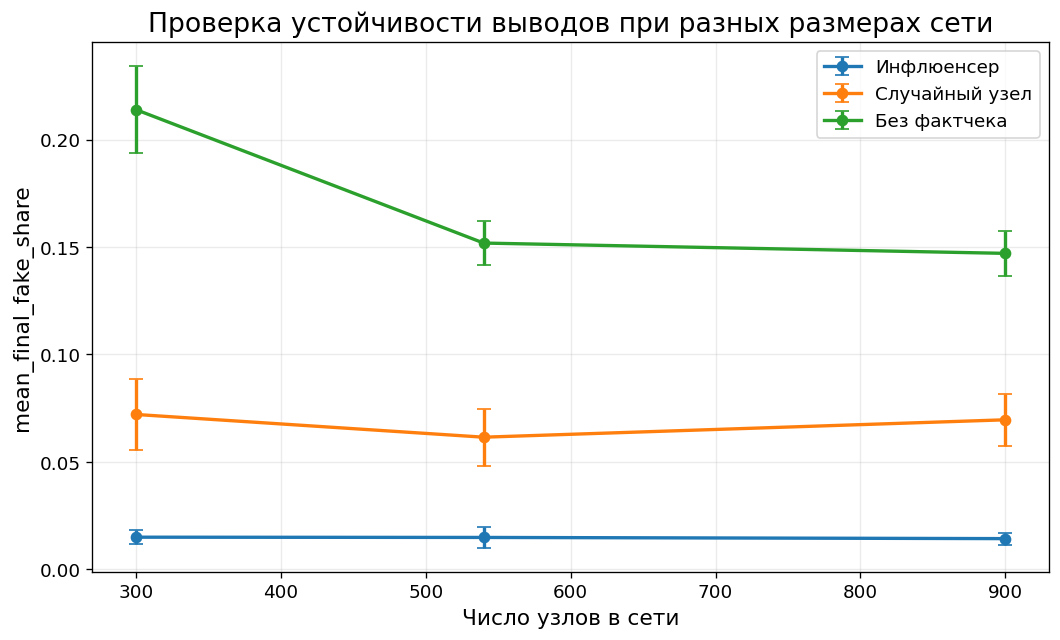

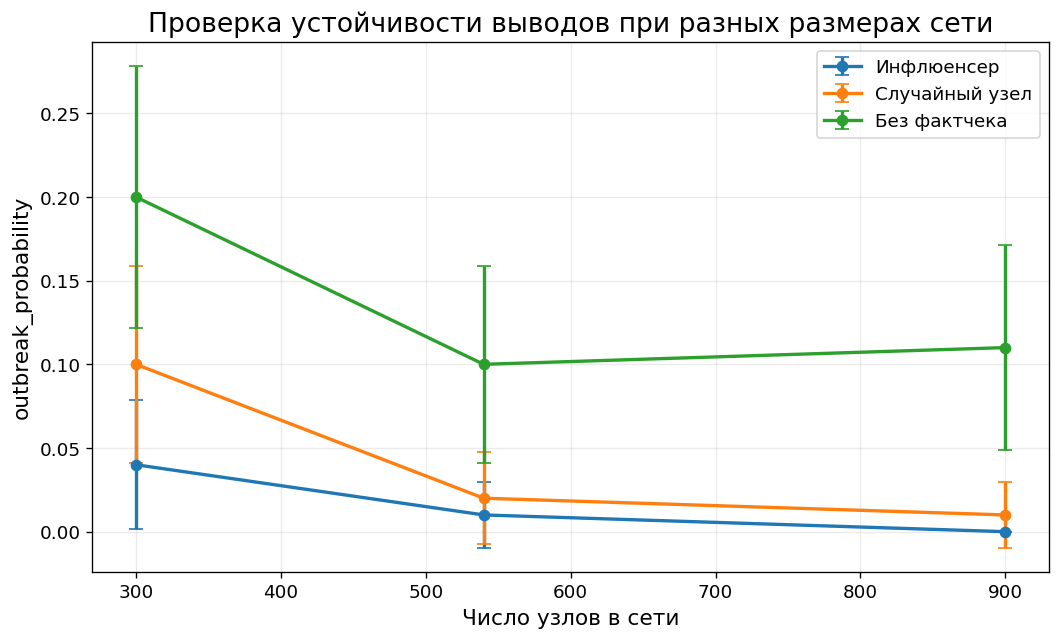

In [ ]:
def scan_network_size_effect(
    community_sizes=(100, 180, 300),
    base_network_kwargs=None,
    strategies=("none", "random", "influencer"),
    n_runs=100,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    records = []

    if base_network_kwargs is None:
        base_network_kwargs = BASE_NETWORK_KWARGS

    for community_size in tqdm(community_sizes, desc="Network sizes"):
        kwargs = base_network_kwargs.copy()
        kwargs["community_size"] = int(community_size)
        kwargs["seed"] = int(rng.integers(1, 1_000_000_000))

        tmp_bundle = generate_echo_chamber_network(**kwargs)
        tmp_G = tmp_bundle.G

        df = compare_factcheck_strategies(
            tmp_G,
            strategies=strategies,
            n_runs=n_runs,
            p=p,
            w=w,
            r=r,
            delay=delay,
            steps=steps,
            fake_community=fake_community,
            outbreak_threshold=outbreak_threshold,
            seed=int(rng.integers(1, 1_000_000_000)),
        )

        summary = strategy_summary_with_ci(df)
        summary["community_size"] = int(community_size)
        summary["total_nodes"] = tmp_G.number_of_nodes()
        summary["edges"] = tmp_G.number_of_edges()
        records.append(summary)

    return pd.concat(records, ignore_index=True)


def plot_network_size_effect(size_df, metric="mean_final_fake_share"):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for strategy in size_df["strategy"].drop_duplicates():
        subset = size_df[size_df["strategy"] == strategy].sort_values("total_nodes")
        ax.errorbar(
            subset["total_nodes"],
            subset[metric],
            yerr=subset.get("final_fake_ci95" if metric == "mean_final_fake_share" else "outbreak_ci95"),
            marker="o",
            linewidth=2,
            capsize=4,
            label=STRATEGY_RU.get(strategy, strategy),
        )

    ax.set_xlabel("Число узлов в сети")
    ax.set_ylabel(metric)
    ax.set_title("Проверка устойчивости выводов при разных размерах сети")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax


network_size_df = scan_network_size_effect(
    community_sizes=(100, 180, 300),
    base_network_kwargs=BASE_NETWORK_KWARGS,
    strategies=("none", "random", "influencer"),
    n_runs=SIZE_RUNS,
    p=0.08,
    w=2.0,
    r=0.35,
    delay=3,
    steps=30,
    fake_community=0,
    outbreak_threshold=0.25,
    seed=SEED,
)

display(network_size_df)

fig_network_size_final, ax_network_size_final = plot_network_size_effect(
    network_size_df,
    metric="mean_final_fake_share",
)


fig_network_size_outbreak, ax_network_size_outbreak = plot_network_size_effect(
    network_size_df,
    metric="outbreak_probability",
)


**Вывод для текста работы:** если линия `Инфлюенсер` остается ниже случайной стратегии и сценария без фактчека при разных размерах сети, можно утверждать, что эффект таргетированного фактчека не является артефактом выбранного размера графа.


## 22. Эксперимент по задержке фактчека


In [ ]:
def scan_delay_effect(
    G,
    delay_values,
    n_runs=150,
    p=0.08,
    w=2.0,
    r=0.35,
    steps=30,
    strategy="influencer",
    fake_community=0,
    outbreak_threshold=0.25,
    seed=42,
):
    rng = np.random.default_rng(seed)
    rows = []

    for delay in tqdm(delay_values, desc="Delay scan"):
        df = run_many(
            G,
            n_runs=n_runs,
            p=p,
            w=w,
            r=r,
            delay=int(delay),
            steps=steps,
            strategy=strategy,
            fake_community=fake_community,
            outbreak_threshold=outbreak_threshold,
            seed=int(rng.integers(1, 1_000_000_000)),
            show_progress=False,
        )

        outbreak_probability = df["outbreak"].mean()

        rows.append(
            {
                "delay": int(delay),
                "runs": n_runs,
                "p": p,
                "w": w,
                "r": r,
                "strategy": strategy,
                "outbreak_probability": outbreak_probability,
                "outbreak_ci95": ci95_for_probability(outbreak_probability, n_runs),
                "mean_final_fake_share": df["final_fake_share"].mean(),
                "std_final_fake_share": df["final_fake_share"].std(),
                "ci95_final_fake_share": ci95_from_std(df["final_fake_share"].std(), n_runs),
                "mean_ever_fake_share": df["ever_fake_share"].mean(),
                "std_ever_fake_share": df["ever_fake_share"].std(),
                "ci95_ever_fake_share": ci95_from_std(df["ever_fake_share"].std(), n_runs),
                "mean_peak_fake_share": df["peak_fake_share"].mean(),
                "std_peak_fake_share": df["peak_fake_share"].std(),
                "ci95_peak_fake_share": ci95_from_std(df["peak_fake_share"].std(), n_runs),
                "mean_final_checked_share": df["final_checked_share"].mean(),
                "mean_time_to_peak": df["time_to_peak"].mean(),
            }
        )

    return pd.DataFrame(rows)


delay_values = [0, 1, 2, 3, 5, 8, 12]

delay_df = scan_delay_effect(
    G,
    delay_values=delay_values,
    n_runs=DELAY_RUNS,
    p=0.08,
    w=2.0,
    r=0.35,
    steps=30,
    strategy="influencer",
    fake_community=0,
    outbreak_threshold=0.25,
    seed=SEED,
)

display(delay_df)


Delay scan:   0%|          | 0/7 [00:00<?, ?it/s]

,delay,runs,p,w,r,strategy,outbreak_probability,outbreak_ci95,mean_final_fake_share,std_final_fake_share,ci95_final_fake_share,mean_ever_fake_share,std_ever_fake_share,ci95_ever_fake_share,mean_peak_fake_share,std_peak_fake_share,ci95_peak_fake_share,mean_final_checked_share,mean_time_to_peak
0,0,300,0.08,2.0,0.35,influencer,0.000000,0.000000,0.009512,0.015307,0.001732,0.044716,0.024287,0.002748,0.031685,0.017541,0.001985,0.698247,1.933333
1,1,300,0.08,2.0,0.35,influencer,0.000000,0.000000,0.009370,0.013741,0.001555,0.045469,0.026036,0.002946,0.032556,0.017816,0.002016,0.676037,1.900000
2,2,300,0.08,2.0,0.35,influencer,0.003333,0.006522,0.014284,0.025870,0.002927,0.069154,0.037997,0.004300,0.048562,0.025417,0.002876,0.690784,2.646667
3,3,300,0.08,2.0,0.35,influencer,0.013333,0.012979,0.017926,0.031490,0.003563,0.088877,0.051171,0.005791,0.063617,0.031833,0.003602,0.693654,3.540000
4,5,300,0.08,2.0,0.35,influencer,0.093333,0.032918,0.023957,0.032923,0.003726,0.142006,0.061830,0.006997,0.110623,0.032145,0.003638,0.670383,4.796667
5,8,300,0.08,2.0,0.35,influencer,0.123333,0.037209,0.026370,0.031840,0.003603,0.156469,0.060525,0.006849,0.142160,0.040201,0.004549,0.684401,6.896667
6,12,300,0.08,2.0,0.35,influencer,0.143333,0.039653,0.026747,0.032561,0.003685,0.160586,0.064677,0.007319,0.156846,0.058905,0.006666,0.677407,8.026667


Смысл эксперимента: фейк стартует сразу, а фактчек появляется через `delay` шагов. Чем больше задержка, тем больше времени у фейка для образования кластера.

Текущие результаты:

| Задержка | Вероятность инфодемии | Финальная доля фейка | Пиковая доля фейка | Хотя бы раз поверили |
|---:|---:|---:|---:|---:|
| 0 | 0.000 | 0.010 | 0.033 | 0.046 |
| 1 | 0.000 | 0.009 | 0.033 | 0.047 |
| 2 | 0.000 | 0.014 | 0.048 | 0.068 |
| 3 | 0.007 | 0.016 | 0.060 | 0.083 |
| 5 | 0.093 | 0.022 | 0.110 | 0.142 |
| 8 | 0.120 | 0.026 | 0.138 | 0.154 |
| 12 | 0.147 | 0.027 | 0.157 | 0.160 |

**Вывод для текста работы:** поздний фактчек может снизить финальный остаток фейка, но не отменяет ранний пик и накопительный ущерб. Поэтому в борьбе с инфодемиями важна не только сила фактчека, но и скорость его появления.

## 23. График влияния задержки


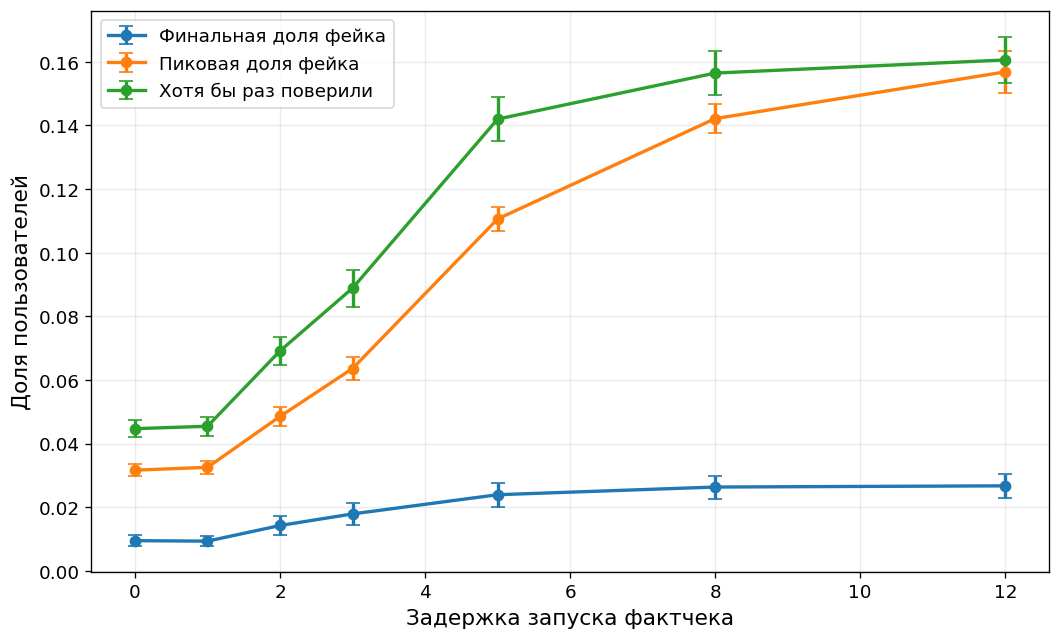

In [ ]:
def plot_delay_effect(delay_df):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    ax.errorbar(
        delay_df["delay"],
        delay_df["mean_final_fake_share"],
        yerr=delay_df.get("ci95_final_fake_share"),
        marker="o",
        linewidth=2,
        capsize=4,
        label="Финальная доля фейка",
    )

    ax.errorbar(
        delay_df["delay"],
        delay_df["mean_peak_fake_share"],
        yerr=delay_df.get("ci95_peak_fake_share"),
        marker="o",
        linewidth=2,
        capsize=4,
        label="Пиковая доля фейка",
    )

    ax.errorbar(
        delay_df["delay"],
        delay_df["mean_ever_fake_share"],
        yerr=delay_df.get("ci95_ever_fake_share"),
        marker="o",
        linewidth=2,
        capsize=4,
        label="Хотя бы раз поверили",
    )

    ax.set_xlabel("Задержка запуска фактчека")
    ax.set_ylabel("Доля пользователей")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax


fig_delay_effect, ax_delay_effect = plot_delay_effect(delay_df)


Обычно финальная доля растет умеренно, а пиковая и накопительная доли растут сильнее. Это означает, что фактчек может «потушить» сеть, но не всегда предотвращает первоначальный ущерб.

**Вывод для текста работы:** задержка фактчека сдвигает систему ближе к сверхкритическому режиму, потому что фейк получает больше времени на образование крупного кластера.

## 24. Оценка минимальной силы фактчека


In [ ]:
def estimate_required_r(
    df,
    p_col="p",
    r_col="r",
    metric_col="mean_final_fake_share",
    target_level=0.05,
):
    rows = []

    for p_value, group in df.groupby(p_col):
        group = group.sort_values(r_col)

        suppressed = group[group[metric_col] <= target_level]

        if suppressed.empty:
            required_r = np.nan
        else:
            required_r = float(suppressed[r_col].iloc[0])

        rows.append(
            {
                "p": float(p_value),
                "target_final_fake_share": target_level,
                "required_r": required_r,
            }
        )

    return pd.DataFrame(rows).sort_values("p").reset_index(drop=True)


required_r_df = estimate_required_r(
    pr_df,
    p_col="p",
    r_col="r",
    metric_col="mean_final_fake_share",
    target_level=0.05,
)

display(required_r_df)

,p,target_final_fake_share,required_r
0,0.020,0.05,0.050
1,0.031,0.05,0.050
2,0.041,0.05,0.050
3,0.052,0.05,0.050
4,0.063,0.05,0.137
5,0.073,0.05,0.180
6,0.084,0.05,0.223
7,0.095,0.05,0.310
8,0.105,0.05,0.353
9,0.116,0.05,0.353


## 25. График минимального `r`


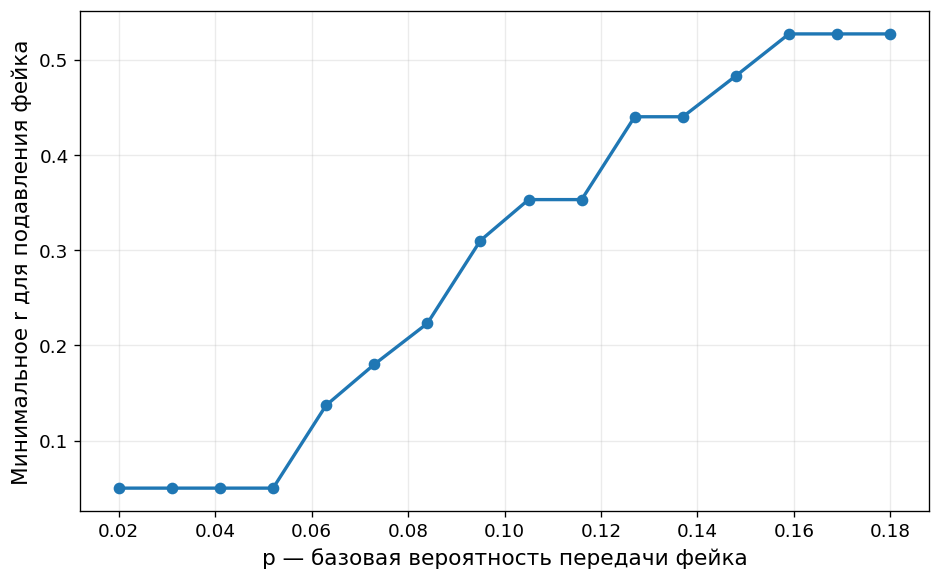

In [ ]:
def plot_required_r(required_r_df):
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        required_r_df["p"],
        required_r_df["required_r"],
        marker="o",
        linewidth=2,
    )

    ax.set_xlabel("p — базовая вероятность передачи фейка")
    ax.set_ylabel("Минимальное r для подавления фейка")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    return fig, ax


fig_required_r, ax_required_r = plot_required_r(required_r_df)

График можно интерпретировать как практическую оценку ресурса: если фейк становится более заразным, платформе или медиасистеме нужно повышать эффективность фактчека, чтобы не допустить устойчивого кластера дезинформации.

**Вывод для текста работы:** зависимость `required_r(p)` показывает перколяционный порог в прикладной форме: это не просто абстрактная граница, а оценка минимального уровня противодействия для разных сценариев распространения фейка.

## 26. Ограничения модели

Эта модель является вычислительным экспериментом на синтетической сети, поэтому ее результаты нужно интерпретировать как модельные, а не как точный прогноз для конкретной социальной платформы.

Основные ограничения:

1. **Синтетическая сеть.** Граф имитирует эхо-камеры, инфлюенсеров и мосты, но не построен по реальным данным пользователей.
2. **Упрощенное доверие к фактчеку.** В базовой версии пользователь, получивший фактчек, переходит в устойчивое состояние `C`. В реальности доверие к опровержениям может различаться между группами.
3. **Однородные параметры.** В модели значения `p`, `w` и `r` одинаковы для всех пользователей, хотя в реальной среде люди отличаются по восприимчивости и уровню доверия.
4. **Одна волна фактчека.** Реальный фактчекинг может запускаться из нескольких источников, иметь разные форматы и разную убедительность.
5. **Порог инфодемии выбран исследователем.** Поэтому в ноутбуке добавлен отдельный анализ чувствительности к этому порогу.

**Как использовать в тексте работы:** ограничения не отменяют результатов, а задают границы их применения. Модель нужна для анализа механизмов и пороговых эффектов: где фейк затухает, где образует крупный кластер и какие точки сети лучше всего подходят для фактчекинга.


## 27. Безопасное сохранение результатов

В финальной ячейке результаты сохраняются в папку `infodemic_outputs`. Графики сохраняются сразу в двух форматах: `.png` для вставки в Word/Google Docs и `.pdf` для более качественной печати или верстки.


In [ ]:
# ===== Safe save results =====

OUTPUT_DIR = "infodemic_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def save_df_if_exists(var_name, filename):
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        path = os.path.join(OUTPUT_DIR, filename)
        globals()[var_name].to_csv(path, index=False)
        print(f"Saved table: {path}")
    else:
        print(f"Skipped table: {var_name}")


def save_matrix_if_exists(matrix_name, index_name, columns_name, filename):
    required = [matrix_name, index_name, columns_name]

    if all(name in globals() for name in required):
        path = os.path.join(OUTPUT_DIR, filename)
        pd.DataFrame(
            globals()[matrix_name],
            index=globals()[index_name],
            columns=globals()[columns_name],
        ).to_csv(path)
        print(f"Saved matrix: {path}")
    else:
        missing = [name for name in required if name not in globals()]
        print(f"Skipped matrix {matrix_name}; missing: {missing}")


def save_fig_if_exists(fig_name, basename):
    """Сохраняет график сразу в PNG и PDF."""
    if fig_name in globals() and globals()[fig_name] is not None:
        fig = globals()[fig_name]
        for ext in ("png", "pdf"):
            path = os.path.join(OUTPUT_DIR, f"{basename}.{ext}")
            fig.savefig(path, dpi=300, bbox_inches="tight")
            print(f"Saved figure: {path}")
    else:
        print(f"Skipped figure: {fig_name}")


# Таблицы
save_df_if_exists("strategy_results", "strategy_results.csv")
save_df_if_exists("strategy_summary", "strategy_summary.csv")
save_df_if_exists("strategy_summary_ci", "strategy_summary_with_ci.csv")
save_df_if_exists("effectiveness_table", "effectiveness_table.csv")

save_df_if_exists("threshold_sensitivity_df", "threshold_sensitivity.csv")
save_df_if_exists("robust_strategy_results", "robust_strategy_results.csv")
save_df_if_exists("robust_by_network_df", "robust_by_network.csv")
save_df_if_exists("robust_strategy_summary", "robust_strategy_summary.csv")
save_df_if_exists("network_size_df", "network_size_effect.csv")

save_df_if_exists("pr_df", "phase_map_p_r.csv")
save_matrix_if_exists("pr_matrix", "r_values", "p_values", "phase_map_p_r_matrix.csv")
save_df_if_exists("critical_p_by_r", "critical_p_by_r.csv")

save_df_if_exists("wr_df", "phase_map_w_r.csv")
save_matrix_if_exists("wr_matrix", "r_values_wr", "w_values", "phase_map_w_r_matrix.csv")
save_df_if_exists("critical_w_by_r", "critical_w_by_r.csv")

save_df_if_exists("bridge_leakage_df", "bridge_leakage_effect.csv")
save_df_if_exists("delay_df", "delay_effect.csv")
save_df_if_exists("required_r_df", "required_r_by_p.csv")

# Графики
save_fig_if_exists("fig_network", "network_structure")
save_fig_if_exists("fig_dyn", "single_simulation_dynamics")
save_fig_if_exists("fig_snapshots", "simulation_snapshots")
save_fig_if_exists("fig_final_state", "final_network_state")

save_fig_if_exists("fig_strategy_fake", "strategy_final_fake_share")
save_fig_if_exists("fig_strategy_outbreak", "strategy_outbreak_probability")
save_fig_if_exists("fig_strategy_box", "strategy_boxplot")
save_fig_if_exists("fig_strategy_final_ci", "strategy_final_fake_share_ci")
save_fig_if_exists("fig_strategy_outbreak_ci", "strategy_outbreak_probability_ci")

save_fig_if_exists("fig_threshold_sensitivity", "threshold_sensitivity")
save_fig_if_exists("fig_robust_final", "robust_strategy_final_fake_share")
save_fig_if_exists("fig_robust_outbreak", "robust_strategy_outbreak_probability")
save_fig_if_exists("fig_network_size_final", "network_size_final_fake_share")
save_fig_if_exists("fig_network_size_outbreak", "network_size_outbreak_probability")

save_fig_if_exists("fig_pr_heatmap", "phase_map_p_r_outbreak_probability")
save_fig_if_exists("fig_pr_final_fake", "phase_map_p_r_final_fake_share")
save_fig_if_exists("fig_pr_peak_fake", "phase_map_p_r_peak_fake_share")

save_fig_if_exists("fig_wr_heatmap", "phase_map_w_r_outbreak_probability")
save_fig_if_exists("fig_wr_final_fake", "phase_map_w_r_final_fake_share")
save_fig_if_exists("fig_wr_peak_fake", "phase_map_w_r_peak_fake_share")

save_fig_if_exists("fig_bridge_leakage", "bridge_leakage_effect")
save_fig_if_exists("fig_bridge_global_leakage", "bridge_global_leakage_probability")

save_fig_if_exists("fig_delay_effect", "delay_effect")
save_fig_if_exists("fig_required_r", "required_r_by_p")

print("\nГотово. Содержимое папки:")
print(os.listdir(OUTPUT_DIR))


Saved table: infodemic_outputs/strategy_results.csv
Saved table: infodemic_outputs/strategy_summary.csv
Saved table: infodemic_outputs/strategy_summary_with_ci.csv
Saved table: infodemic_outputs/effectiveness_table.csv
Saved table: infodemic_outputs/threshold_sensitivity.csv
Saved table: infodemic_outputs/robust_strategy_results.csv
Saved table: infodemic_outputs/robust_by_network.csv
Saved table: infodemic_outputs/robust_strategy_summary.csv
Saved table: infodemic_outputs/network_size_effect.csv
Saved table: infodemic_outputs/phase_map_p_r.csv
Saved matrix: infodemic_outputs/phase_map_p_r_matrix.csv
Saved table: infodemic_outputs/critical_p_by_r.csv
Saved table: infodemic_outputs/phase_map_w_r.csv
Saved matrix: infodemic_outputs/phase_map_w_r_matrix.csv
Saved table: infodemic_outputs/critical_w_by_r.csv
Saved table: infodemic_outputs/bridge_leakage_effect.csv
Saved table: infodemic_outputs/delay_effect.csv
Saved table: infodemic_outputs/required_r_by_p.csv
Saved figure: infodemic_outp

# Итоговые выводы для текстовой части работы

Ниже собраны формулировки, которые можно использовать при написании разделов «Методология», «Результаты», «Обсуждение» и «Ограничения».

## Методологический вывод

В работе построена графовая модель инфодемии, где пользователи представлены узлами, социальные связи — ребрами, а распространение фейка и фактчека — конкурирующими перколяционными процессами. Сеть состоит из нескольких эхо-камер с плотными внутренними связями и редкими межгрупповыми мостами. Такая структура позволяет моделировать локальное распространение фейка внутри поляризованной группы и его возможный переход в другие сообщества.

## Вывод по стратегиям фактчека

Наиболее эффективной стратегией является запуск фактчека через инфлюенсера в исходной эхо-камере. Эта стратегия снижает финальную долю пользователей, верящих в фейк, сильнее, чем случайный фактчек. Случайные стратегии тоже могут снижать охват, но имеют более высокий разброс и меньшую предсказуемость.

## Вывод по фазовой карте `p × r`

Фазовые карты `p × r` показывают перколяционный переход: при низкой заразности фейка или высокой силе фактчека фейк затухает, а при росте `p` образуется крупный кластер зараженных пользователей. Чем выше базовая вероятность передачи фейка, тем большее значение `r` требуется для удержания финальной доли фейка ниже заданного порога.

## Вывод по фазовой карте `w × r`

Карта `w × r` показывает, как эмоциональное усиление фейка меняет требуемую силу фактчека. При росте `w` фейк становится заразнее, поэтому для подавления инфодемии требуется большее значение `r`. Этот результат связывает математическую модель с тезисом о том, что эмоционально окрашенные фейки распространяются быстрее.

## Вывод по мостам между эхо-камерами

Межгрупповые мосты резко повышают риск перехода фейка из локальной эхо-камеры в другие сообщества. При отсутствии мостов межгрупповая утечка не возникает, а при увеличении числа мостов вероятность перехода фейка в другие группы растет. Следовательно, мостовые связи являются каналами глобальной перколяции.

## Вывод по задержке фактчека

Даже эффективный фактчек теряет часть силы при задержке. Чем позже запускается фактчек, тем выше пиковый охват фейка и накопительная доля пользователей, которые хотя бы раз поверили в него. Это показывает, что для борьбы с инфодемиями важна не только сила фактчекинга, но и скорость реакции.

## Вывод по устойчивости результатов

Проверка на нескольких случайных сетях нужна для того, чтобы показать: результаты не являются особенностью одного конкретного графа. Если стратегия инфлюенсера остается лучшей на разных реализациях сети, вывод можно считать более надежным.

## Ограничения модели

1. **Сеть синтетическая.** В работе не используются реальные данные социальных платформ, поэтому результаты следует трактовать как модельные, а не как точный прогноз для конкретной сети.
2. **Фактчек считается устойчивым состоянием.** Если пользователь получил фактчек, он больше не заражается фейком. В реальности доверие к фактчеку может различаться между группами.
3. **Порог инфодемии задан как параметр.** В ноутбуке добавлена проверка нескольких порогов, но сам выбор порога все равно является исследовательским допущением.
4. **Содержательная часть фейков не моделируется.** Параметр `w` агрегирует эмоциональность и вирусность, но не описывает конкретные темы, нарративы или качество источника.
5. **Время дискретно.** Модель работает по шагам, а не в непрерывном времени.

## Общий итог

Модель подтверждает главную гипотезу: массовая инфодемия возникает не только из-за высокой эмоциональности и заразности фейка, но и из-за структуры сети. Чтобы эффективно подавлять фейки, нужно воздействовать на ключевые узлы — инфлюенсеров, высокосвязные узлы и мосты между сообществами — а также минимизировать задержку запуска фактчека.


In [ ]:
from google.colab import files

!zip -r infodemic_outputs.zip infodemic_outputs
files.download("infodemic_outputs.zip")

updating: infodemic_outputs/ (stored 0%)
updating: infodemic_outputs/simulation_snapshots.png (deflated 13%)
updating: infodemic_outputs/network_size_effect.csv (deflated 60%)
updating: infodemic_outputs/strategy_boxplot.pdf (deflated 38%)
updating: infodemic_outputs/robust_strategy_outbreak_probability.png (deflated 19%)
updating: infodemic_outputs/bridge_global_leakage_probability.png (deflated 16%)
updating: infodemic_outputs/bridge_leakage_effect.csv (deflated 68%)
updating: infodemic_outputs/strategy_outbreak_probability.png (deflated 18%)
updating: infodemic_outputs/phase_map_p_r.csv (deflated 80%)
updating: infodemic_outputs/phase_map_w_r_outbreak_probability.pdf (deflated 32%)
updating: infodemic_outputs/network_structure.png (deflated 8%)
updating: infodemic_outputs/threshold_sensitivity.csv (deflated 80%)
updating: infodemic_outputs/robust_strategy_final_fake_share.png (deflated 20%)
updating: infodemic_outputs/final_network_state.pdf (deflated 6%)
updating: infodemic_outputs

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>